In [ ]:
# Engineering Process Control
# Pendekatan mengendalikan proses secara aktif menggunakan model proses + feedback, bukan hanya memonitor output
# SPC -> deteksi masalah (Alarm), EPC -> koreksi masalah (Steering Wheel)
# model: Y_t = betaX_t + d_t
# dimana:
# Y_t adalah output(misal diameter)
# X_t adalah input yang bisa dikontrol(misal offset mesin)
# d_t adalah disturbance(mis: tool wear, temperature, dll)
# EPC mengubah X berdasarkan error di Y
# misal target diameter = 20.00 mm dan output terbaca = 20.03 mm
# EPC> berapa offset spindle yang harus dikurangi supaya output kembali le 20.00 mm?

In [ ]:
# JENIS–JENIS PENENTUAN THRESHOLD MPSC

# PETA BESAR (biar tidak bingung)
# Statistik	            Threshold umum
# Hotelling T²	        Distribusi F / Chi-square
# Q-statistic (SPE)	    Jackson–Mudholkar
# T² & Q	            Empirical / Percentile
# Semua	                Bootstrap
# Modern	            False Alarm Rate (FAR)

# T² Threshold – Distribusi F (Klasik SPC)
# Konsep
# Digunakan saat: data normal, Phase I cukup, paling textbook (Montgomery, dll)
# Untuk PCA / PLS latent score:
# UCL_{T^2} = \frac{a(n-1)}{n-a} F_{a,n-a,\alpha}
# a = jumlah latent variable
# n = sample Phase I
# Code
from scipy.stats import f
def T2_limit_F(a, n, alpha=0.99):
    return (a(n-1)/(n-a))  f.ppf(alpha, a, n-a)
UCL_T2 = T2_limit_F(a=2, n=35)
# Interpretasi engineering
# Kalau T² melewati UCL → kondisi proses keluar dari ruang operasi normal
# Biasanya drift sistemik (tool wear, thermal shift).


# T² Threshold – Chi-Square (Asymptotic)
# Konsep
# Dipakai saat:
# sample besar
# pendekatan sederhana
# T^2 \sim \chi^2_a
# Code
from scipy.stats import chi2
UCL_T2_chi = chi2.ppf(0.99, df=2)
# Interpretasi
# Lebih longgar dari F-based.
# Dipakai untuk monitoring online.

# Q-Statistic Threshold – Jackson–Mudholkar (WAJIB TAHU)
# Konsep
# Q-statistic = residual PCA / PLS
# Jackson–Mudholkar approximation:
# Q_\alpha = \theta_1 \left[\frac{z_\alpha \sqrt{2\theta_2 h_0^2}}{\theta_1}+ 1+ \frac{\theta_2 h_0(h_0-1)}{\theta_1^2}\right]^{1/h_0}
# Code
import numpy as np
from scipy.stats import norm
def Q_limit_JM(eigenvalues, alpha=0.99):
    theta1 = np.sum(eigenvalues)
    theta2 = np.sum(eigenvalues2)
    theta3 = np.sum(eigenvalues3)
    h0 = 1 - (2theta1theta3)/(3theta22)
    z = norm.ppf(alpha)
    return theta1  (
        (znp.sqrt(2theta2h02))/theta1
        + 1
        + (theta2h0(h0-1))/(theta12)
    )(1/h0)
# Interpretasi engineering
# > Q tinggi → ada variasi yang tidak bisa dijelaskan model normal
# Biasanya:
# misalignment, sensor failure, dan localized fault
# Ini threshold paling penting di latent MPSC.


# Empirical Threshold (Percentile-Based) – PALING PRAKTIS
# Konsep
# Dipakai saat:
# data tidak normal
# engineer tidak mau ribet asumsi
# data Phase I cukup
# Code
def empirical_limit(statistic, alpha=0.99):
    return np.percentile(statistic, alpha100)
UCL_T2_emp = empirical_limit(T2_phase1)
UCL_Q_emp  = empirical_limit(Q_phase1)
# Interpretasi
# > “Dari data normal historis, hanya 1% yang lebih ekstrem”
# Ini paling sering dipakai di pabrik modern.


# Bootstrap Threshold – Robust & Industrial Grade
# Konsep
# Dipakai saat:
# distribusi unknown
# nonlinear
# sensor banyak
# Code
def bootstrap_limit(statistic, B=1000, alpha=0.99):
    boot = []
    for _ in range(B):
        sample = np.random.choice(statistic, size=len(statistic), replace=True)
        boot.append(np.percentile(sample, alpha100))
    return np.mean(boot)
# Interpretasi
# > Threshold mencerminkan variabilitas real proses, bukan teori statistik murni.
# Dipakai di:
# semiconductor
# pharma
# advanced manufacturing


# FAR-Based Threshold (Modern SPC / ML Monitoring)
# Konsep
# Engineer menentukan:
# > “Saya mau false alarm 1 alarm per 100 sample”
# Code
def FAR_limit(statistic, FAR=0.01):
    return np.quantile(statistic, 1-FAR)
# Interpretasi
# Ini bridge SPC ↔ ML
# Dipakai di:
# anomaly detection
# predictive maintenance

In [ ]:
# Run-to-Run Engineering Process Control (R2R)

# Konteks Engineering (penting)
# Proses
# Turning shaft diameter
# Karakteristik kualitas (Y)
# Diameter (mm)
# Target
# ( T = 20.00 ) mm
# Input yang bisa dikontrol (X)
# Offset mesin (mm)
# Gangguan nyata
# Tool wear → menyebabkan drift positif (diameter makin besar)
# Tujuan EPC:
# menghitung offset baru agar output kembali ke target setiap run.

import pandas as pd
import numpy as np

np.random.seed(0)

n_runs = 25
target = 20.00
beta = 1.0

df = pd.DataFrame({
    "run": range(1, n_runs + 1)
})

# tool wear → drift kecil positif tiap run
df["disturbance"] = np.linspace(0, 0.04, n_runs)

df["offset"] = 0.0
df["output_diameter"] = 0.0


# Simulasi EPC Run-to-Run

for i in range(n_runs):
    if i == 0:
        offset = 0.0
    else:
        offset = df.loc[i-1, "offset"]

    disturbance = df.loc[i, "disturbance"]
    
    # output proses
    y = target + beta  offset + disturbance + np.random.normal(0, 0.002)
    
    # EPC update rule
    new_offset = offset + (target - y) / beta
    
    df.loc[i, "output_diameter"] = y
    df.loc[i, "offset"] = new_offset

df.head()

,run,disturbance,offset,output_diameter
0,1,0.000000,-0.003528,20.003528
1,2,0.001667,-0.002467,19.998939
2,3,0.003333,-0.005291,20.002824
3,4,0.005000,-0.009482,20.004191
4,5,0.006667,-0.010402,20.000920


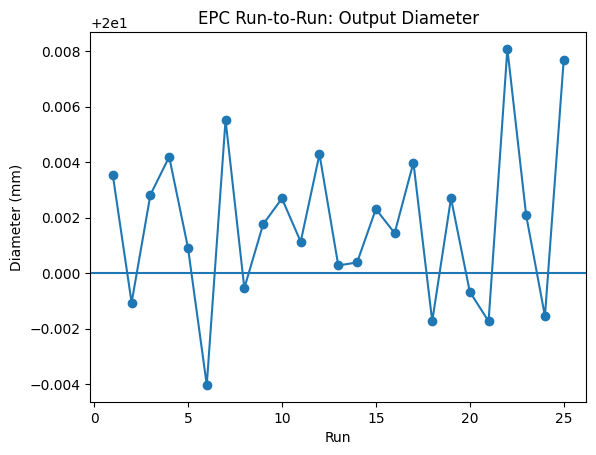

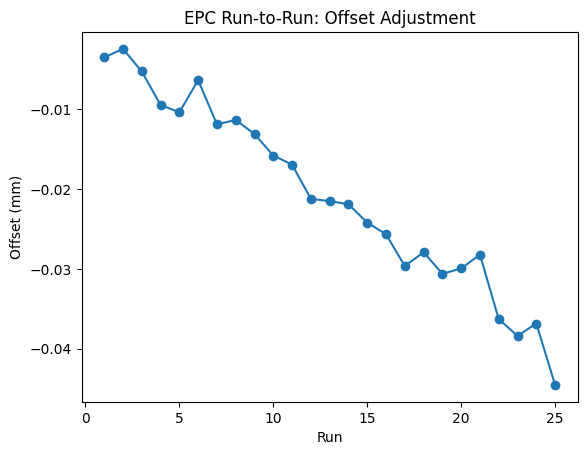

In [ ]:
## 5️⃣ Visualisasi (tanpa style khusus)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["output_diameter"], marker="o")
plt.axhline(target)
plt.xlabel("Run")
plt.ylabel("Diameter (mm)")
plt.title("EPC Run-to-Run: Output Diameter")
plt.show()

plt.figure()
plt.plot(df["run"], df["offset"], marker="o")
plt.xlabel("Run")
plt.ylabel("Offset (mm)")
plt.title("EPC Run-to-Run: Offset Adjustment")
plt.show()

# Cerita PALING sederhana
# Kasus nyata (bayangkan ini)
# Mesin bubut
# Target diameter: 20.00 mm
# Anda ukur 1 part setiap run
# Tool pelan-pelan aus
# Tanpa EPC (cara lama)
# Run 1 → 20.00
# Run 2 → 20.01
# Run 3 → 20.02
# Run 4 → 20.03
# SPC bilang:
# “Masih aman… masih aman… masih aman…”
# Tapi Anda tahu:
# “Ini bakal jeblos bentar lagi.”
# Dengan EPC (cara engineer)
# Run 3 hasil = 20.02
# Engineer berpikir:
# “Oke, kebesaran 0.02.
# Kalau aku geser offset mesin –0.02, next part harus balik ke 20.00.”

# SELESAI
# Tidak nunggu alarm.
# Tidak nunggu reject.

# pantas saja run to run offset adjusmentnya kok semakin ke bawah? 
# ternyata engineer hanya mengikuti drift yang terjadi, karena disini diameter semakin naik terus, ya wajar offset adjument semakin menurun(ada offset naik tpi bberapa saja)
# Engineer hanya mengikuti drift yang terjadi. Karena diameter makin naik, offset makin diturunkan.

In [ ]:
# MULTIVARIATE CUSUM (MCUSUM)
# Kenapa “multivariate” dibutuhkan?
# Anda sudah paham:
# Univariate CUSUM → 1 karakteristik kualitas
# Tapi di pabrik nyata:
# diameter
# roundness
# surface roughness
# vibration
# temperature
# Semua saling berkorelasi.
# Masalahnya:
# Semua variabel bisa terlihat “aman” sendiri-sendiri,
# tapi kombinasi mereka sudah berubah.
# Itulah kenapa multivariate CUSUM lahir.

# Intuisi PALING sederhana
# Bayangkan ini:
# Diameter naik sedikit (masih OK)
# Roughness naik sedikit (masih OK)
# Temperatur naik sedikit (masih OK)
# Tapi naiknya searah & konsisten.
# Univariate chart: diam
# Multivariate CUSUM: “eh… ini aneh”
# Kalimat kunci:
# Multivariate CUSUM mendengar bisikan yang datang serempak dari banyak variabel.

# Apa yang sebenarnya dihitung? (tanpa rumus berat)
# Multivariate CUSUM:
# Lihat vektor deviasi dari target
# Perhitungkan: arah perubahan, besar perubahan, korelasi antar variabel, dam Akumulasi deviasi tersebut dari waktu ke waktu
# Kalau deviasi:
# acak → saling meniadakan
# searah → akumulasi membesar

# Contoh mental (penting)
# Proses machining
# Variabel:
# Y1 = diameter
# Y2 = vibration RMS
# Y3 = temperatur
# Tool wear menyebabkan:
# vibration ↑
# temperature ↑
# diameter ↑
# Multivariate CUSUM melihat pola degradasi, bukan cuma angka satuan.

In [ ]:
# MCUSUM

# Konteks Engineering (ini kunci)
# Proses
#  Turning / machining shaft
# Variabel kualitas (berkorelasi)
# 1. `diameter_mm` → output utama
# 2. `vibration_rms` → indikasi tool wear
# 3. `temperature_c` → indikasi thermal & friction
# Fenomena fisik
# Tool wear →
#  diameter ↑, vibration ↑, temperature ↑
# Drift kecil tapi konsisten
# Target MCUSUM:
# mendeteksi drift kolektif ini lebih cepat daripada chart satuan.

# Data Sintetis (DataFrame, jelas kolomnya)

import pandas as pd
import numpy as np

np.random.seed(1)

n = 40
df = pd.DataFrame({
    "run": range(1, n + 1)
})

# baseline (in-control)
df["diameter_mm"] = 20.00 + np.random.normal(0, 0.002, n)
df["vibration_rms"] = 2.0 + np.random.normal(0, 0.05, n)
df["temperature_c"] = 30.0 + np.random.normal(0, 0.3, n)

# introduce small drift after run 15 (tool wear)
for i in range(15, n):
    df.loc[i, "diameter_mm"] += 0.002  (i - 14)
    df.loc[i, "vibration_rms"] += 0.03  (i - 14)
    df.loc[i, "temperature_c"] += 0.2  (i - 14)

df.head()

,run,diameter_mm,vibration_rms,temperature_c
0,1,20.003249,1.990408,29.933302
1,2,19.998776,1.955619,29.939773
2,3,19.998944,1.962642,30.055968
3,4,19.997854,2.084623,30.123015
4,5,20.001731,2.002540,30.059490


In [5]:
# Standarisasi & Korelasi (inti multivariate)

# MCUSUM tidak pakai data mentah langsung.
# Kita:
# 1. Center ke mean
# 2. Scale ke standar deviasi
# 3. Perhitungkan korelasi

from numpy.linalg import inv

features = ["diameter_mm", "vibration_rms", "temperature_c"]

X = df[features].values

mu = X[:15].mean(axis=0)        # baseline mean (Phase I)
cov = np.cov(X[:15].T)          # baseline covariance
inv_cov = inv(cov)

# standardized deviation
Z = X - mu

In [6]:
# Hitung Multivariate CUSUM Statistic
# Versi sederhana MCUSUM (vector-based):

# C_t = \sqrt{Z_t^T \Sigma^{-1} Z_t}

# lalu diakumulasikan

cusum = []
S = 0

for z in Z:
    stat = np.sqrt(z.T @ inv_cov @ z)
    S = max(0, S + stat - 1.0)   # k = 1.0 (reference value)
    cusum.append(S)

df["mcusum"] = cusum
df.head()

,run,diameter_mm,vibration_rms,temperature_c,mcusum
0,1,20.003249,1.990408,29.933302,0.505890
1,2,19.998776,1.955619,29.939773,0.642410
2,3,19.998944,1.962642,30.055968,0.695945
3,4,19.997854,2.084623,30.123015,1.764300
4,5,20.001731,2.002540,30.059490,1.522830


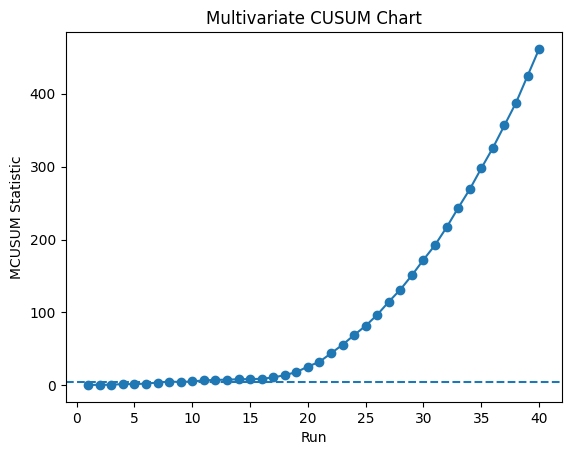

In [ ]:
# Visualisasi MCUSUM

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["mcusum"], marker="o")
plt.axhline(5, linestyle="--")   # decision threshold
plt.xlabel("Run")
plt.ylabel("MCUSUM Statistic")
plt.title("Multivariate CUSUM Chart")
plt.show()

# INTERPRETASI ENGINEERING (INI PALING PENTING)

# Interpretasi 1 — sebelum drift
# Run 1–15:
# MCUSUM ≈ 0
# Artinya:
# kombinasi diameter, vibration, temperature masih seimbang

# Interpretasi 2 — setelah run 15

# MCUSUM naik perlahan tapi konsisten
# Tidak ada lonjakan besar di satu variabel
# Makna engineering:
# > Ada degradasi proses kolektif,
# > bukan noise satuan.

# ###  Interpretasi 3 — dibanding univariate
# Diameter sendiri: masih “dalam spec”
# Vibration sendiri: masih “wajar”
# Temperature sendiri: belum alarm
# MCUSUM sudah teriak duluan.

In [ ]:
# Multivariate Process Statistical Control (MPSC)

# Hotelling’s T² Chart
# Hotelling’s T² adalah:
# > generalization dari X̄-chart ke multivariate

# 2.1 Ide besar Hotelling’s T²
# Univariate:
# Z = \frac{(\bar{X} - \mu)^2}{\sigma^2}
# Multivariate:
# T^2 = (\bar{\mathbf{X}} - \boldsymbol{\mu})^T\mathbf{S}^{-1}(\bar{\mathbf{X}} - \boldsymbol{\mu})
# Maknanya:
#jarak kuadrat dari mean proses
# tapi:
# mempertimbangkan skala
# mempertimbangkan korelasi

# Kalimat penting:
# > T² = seberapa “aneh” posisi proses saat ini dibandingkan pola normalnya

# Apa yang diuji oleh T²?
# Bukan:
# tiap variabel satu per satu
# Tapi:
# kombinasi semua variabel sekaligus
# Bisa terjadi:
# semua variabel masih “dalam limit”
#  tapi T² out-of-control

# MPSC Hotelling T² – Dua Kasus Penting
# a️ T² Chart untuk Subgroup Data
# Struktur data
# Tiap waktu → ambil n sampel
# Hitung mean tiap variabel dalam subgroup
# Mean vector inilah yang diplot
# Digunakan ketika:
# produksi stabil
# sampling terstruktur
# variasi within-subgroup bermakna
# Statistik:
# T^2_i = n (\bar{\mathbf{X}}_i - \boldsymbol{\mu})^T\mathbf{S}^{-1}(\bar{\mathbf{X}}_i - \boldsymbol{\mu})
# Makna konseptual:
# > Apakah pusat subgroup menyimpang dari pusat proses multivariat?
# b️ T² Chart untuk Individual Observation
# Ini sering muncul di manufaktur modern.
# Struktur data
# n = 1
# Tiap waktu hanya satu observasi vektor
# Digunakan ketika:
# metrology mahal
# proses kontinu
# high-mix low-volume
# Statistik:
# T^2_i = (\mathbf{X}_i - \boldsymbol{\mu})^T\mathbf{S}^{-1}(\mathbf{X}_i - \boldsymbol{\mu})
# Perbedaan penting:
# tidak ada averaging
# lebih sensitif
# lebih noisy

In [ ]:
# KONTEKS PROSES (SAMA UNTUK KEDUA KASUS)

# Proses: machining shaft
# Variabel kualitas (berkorelasi):
# diameter_mm
# roundness_um
# surface_ra_um
# Fenomena fisik:
# tool wear → semua variabel drift bersama

# HOTELLING T² – SUBGROUP DATA
# Data Subgroup (n = 5 per subgroup)

import numpy as np
import pandas as pd

np.random.seed(0)

n_subgroup = 20
n_sample = 5

rows = []

for g in range(n_subgroup):
    drift = max(0, g - 10)  0.002  # drift setelah subgroup 10
    
    for i in range(n_sample):
        rows.append({
            "subgroup": g + 1,
            "diameter_mm": 20.00 + drift + np.random.normal(0, 0.002),
            "roundness_um": 3.0 + drift + np.random.normal(0, 0.2),
            "surface_ra_um": 1.2 + drift + np.random.normal(0, 0.1)
        })

df = pd.DataFrame(rows)
df.head()

,subgroup,diameter_mm,roundness_um,surface_ra_um
0,1,20.003528,3.080031,1.297874
1,1,20.004482,3.373512,1.102272
2,1,20.001900,2.969729,1.189678
3,1,20.000821,3.028809,1.345427
4,1,20.001522,3.024335,1.244386


In [11]:
# Mean Vector per Subgroup

features = ["diameter_mm", "roundness_um", "surface_ra_um"]

group_mean = df.groupby("subgroup")[features].mean()

In [12]:
# Phase I Estimation(Baseline)

baseline = group_mean.iloc[:10]   # Phase I

mu = baseline.mean().values
S = np.cov(baseline.T)
S_inv = np.linalg.inv(S)

In [ ]:
# Hitung Hotelling T^2 (Subgroup)

T2 = []

for _, row in group_mean.iterrows():
    diff = row.values - mu
    T2.append(diff.T @ S_inv @ diff)

group_mean["T2"] = T2
group_mean.head()

from scipy.stats import f

def T2_limit_F(a, n, alpha=0.99):
    return (a(n-1)/(n-a))  f.ppf(alpha, a, n-a)
UCL_T2 = T2_limit_F(a=2, n=35)

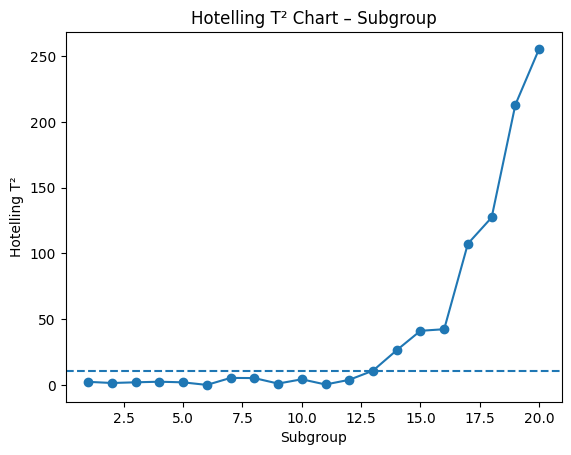

In [15]:
# Plot T^2 Subgroup

import matplotlib.pyplot as plt

plt.figure()
plt.plot(group_mean.index, group_mean["T2"], marker="o")
plt.axhline(y=UCL_T2, linestyle="--")   # illustrative limit
plt.xlabel("Subgroup")
plt.ylabel("Hotelling T²")
plt.title("Hotelling T² Chart – Subgroup")
plt.show()

# INTERPRETASI ENGINEERING (SUBGROUP)
# Subgroup 1–10:
# T² rendah & stabil
# kombinasi karakteristik masih normal
# Setelah subgroup 11:
# T² naik konsisten
# Artinya:
# mean multivariat proses bergeser,
# bukan hanya satu karakteristik
# Cocok sebagai alarm sistemik, bukan inspeksi satuan

In [ ]:
# T^2 individual observation data

np.random.seed(1)

n_obs = 40
rows = []

for i in range(n_obs):
    drift = max(0, i - 20)  0.002
    
    rows.append({
        "run": i + 1,
        "diameter_mm": 20.00 + drift + np.random.normal(0, 0.003),
        "roundness_um": 3.0 + drift50 + np.random.normal(0, 0.3),
        "surface_ra_um": 1.2 + drift20 + np.random.normal(0, 0.15)
    })

df_ind = pd.DataFrame(rows)
df_ind.head()

,run,diameter_mm,roundness_um,surface_ra_um
0,1,20.004873,2.816473,1.120774
1,2,19.996781,3.259622,0.854769
2,3,20.005234,2.771638,1.247856
3,4,19.999252,3.438632,0.890979
4,5,19.999033,2.884784,1.370065


In [19]:
# Phase 1 Estimation

baseline = df_ind.iloc[:20][features]

mu = baseline.mean().values
S = np.cov(baseline.T)
S_inv = np.linalg.inv(S)

In [20]:
# Hitung T^2 Individual

T2 = []

for _, row in df_ind.iterrows():
    diff = row[features].values - mu
    T2.append(diff.T @ S_inv @ diff)

df_ind["T2"] = T2
df_ind.head()

,run,diameter_mm,roundness_um,surface_ra_um,T2
0,1,20.004873,2.816473,1.120774,3.982284
1,2,19.996781,3.259622,0.854769,5.411196
2,3,20.005234,2.771638,1.247856,4.355855
3,4,19.999252,3.438632,0.890979,5.506491
4,5,19.999033,2.884784,1.370065,1.489796


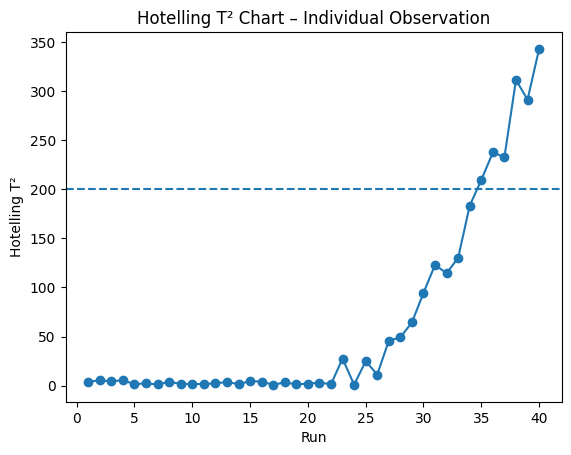

In [28]:
# Plot T^2 Individual 

plt.figure()
plt.plot(df_ind["run"], df_ind["T2"], marker="o")
plt.axhline(200, linestyle="--")   # illustrative limit
plt.xlabel("Run")
plt.ylabel("Hotelling T²")
plt.title("Hotelling T² Chart – Individual Observation")
plt.show()

# INTERPRETASI ENGINEERING (INDIVIDUAL)
# Noise lebih besar dibanding subgroup

# Tapi:
# setelah run ~22
# T² naik terus
# Makna:
# perubahan kecil tapi terkoordinasi antar variabel,
# terdeteksi lebih cepat daripada chart univariate

In [ ]:
# MEWMA (Multivariate Exponentially Weighted Moving Average)

# Intuisi dulu (tanpa rumus)
# Anda sudah paham:
# Shewhart → lihat titik
# CUSUM → akumulasi error
# Hotelling T² → jarak multivariat
# MEWMA itu:
# > CUSUM versi “halus” + multivariat
# Alih-alih menjumlahkan error secara keras,
# MEWMA:
# menghaluskan data multivariat dari waktu ke waktu
# memberi bobot lebih besar ke data terbaru
# tetap mempertahankan struktur kovarians
# Kalimat kunci:
# > MEWMA mendengar perubahan kecil lebih cepat, tapi dengan noise lebih jinak daripada T² individual.

# Bentuk konseptual (tanpa detail matematis)
# MEWMA membangun vektor EWMA:
# \mathbf{Z}_t = \lambda \mathbf{X}t + (1-\lambda)\mathbf{Z}{t-1}
# Maknanya:
#  (\mathbf{X}_t) = observasi multivariat saat ini
# (\mathbf{Z}_t) = “ingatan proses”
# (\lambda) = seberapa cepat kita bereaksi

# Apa yang dipantau MEWMA?
# Yang dipantau bukan X langsung, tapi:
# > trajektori vektor rata-rata bergerak dalam ruang multivariat
# Lalu dipakai statistik:
# T^2_{\text{MEWMA}} = \mathbf{Z}_t^T \Sigma_Z^{-1} \mathbf{Z}_t
# Konsepnya sama dengan Hotelling T²,
#bedanya:
# inputnya vektor terhaluskan

#.4 Kenapa MEWMA penting secara engineering?
# Karena banyak degradasi: pelan. terkoordinasi, dan persisten
# Tool wear, fouling, thermal drift → ideal untuk MEWMA.
# Perbandingan cepat:
# | Tool   | Kuat untuk           |
# | ------ | -------------------- |
# | T²     | Anomali instan       |
# | MCUSUM | Drift kecil tajam    |
# | MEWMA  | Drift kecil smooth   |


In [ ]:
# IMPLEMENTASI MEWMA
# Multivariate EWMA Control Chart

# KONTEKS PROSES (REALISTIS)
# Proses: machining shaft
# Variabel kualitas (berkorelasi):
# diameter_mm
# roundness_um
# surface_ra_um
# Fenomena fisik:
# tool wear → drift pelan & smooth
# data berisik → Shewhart T² terlalu sensitif
# MEWMA dipilih karena:
# drift kecil + noise + multivariate

import numpy as np
import pandas as pd

np.random.seed(42)

n = 50
rows = []

for t in range(n):
    drift = max(0, t - 20)  0.001  # drift pelan setelah t=20
    
    rows.append({
        "run": t + 1,
        "diameter_mm": 20.00 + drift + np.random.normal(0, 0.002),
        "roundness_um": 3.0 + drift60 + np.random.normal(0, 0.25),
        "surface_ra_um": 1.2 + drift25 + np.random.normal(0, 0.12)
    })

df = pd.DataFrame(rows)
df.head()

,run,diameter_mm,roundness_um,surface_ra_um
0,1,20.000993,2.965434,1.277723
1,2,20.003046,2.941462,1.171904
2,3,20.003158,3.191859,1.143663
3,4,20.001085,2.884146,1.144112
4,5,20.000484,2.521680,0.993010


In [23]:
# Phase 1: Mean Vector dan Covariance

features = ["diameter_mm", "roundness_um", "surface_ra_um"]

baseline = df.iloc[:20][features]   # Phase I

mu = baseline.mean().values
Sigma = np.cov(baseline.T)
Sigma_inv = np.linalg.inv(Sigma)

In [ ]:
# Bangun MEWMA 

lambda_ = 0.2   # smoothing parameter

Z = np.zeros(len(features))
Z_list = []

for _, row in df.iterrows():
    X = row[features].values - mu
    Z = lambda_  X + (1 - lambda_)  Z
    Z_list.append(Z.copy())

Z_df = pd.DataFrame(Z_list, columns=[f"Z_{c}" for c in features])

In [ ]:
# Statistik MEWMA (Hotelling-type T^2)

Sigma_Z = (lambda_ / (2 - lambda_))  Sigma
Sigma_Z_inv = np.linalg.inv(Sigma_Z)

T2_mewma = []

for _, z in Z_df.iterrows():
    z = z.values
    T2_mewma.append(z.T @ Sigma_Z_inv @ z)

df["T2_MEWMA"] = T2_mewma
df.head()

,run,diameter_mm,roundness_um,surface_ra_um,T2_MEWMA
0,1,20.000993,2.965434,1.277723,0.561890
1,2,20.003046,2.941462,1.171904,2.764909
2,3,20.003158,3.191859,1.143663,6.670321
3,4,20.001085,2.884146,1.144112,5.765093
4,5,20.000484,2.521680,0.993010,4.779971


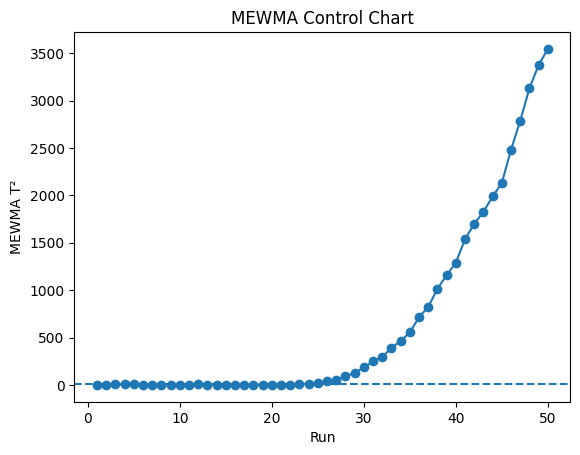

In [ ]:
# Plot MEWMA

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["T2_MEWMA"], marker="o")
plt.axhline(7, linestyle="--")   # illustrative control limit
plt.xlabel("Run")
plt.ylabel("MEWMA T²")
plt.title("MEWMA Control Chart")
plt.show()

# INTERPRETASI ENGINEERING (INI INTINYA)
# Sebelum drift (run 1–20)
# MEWMA T² kecil & stabil
# Variasi:
# dianggap common cause multivariate
#  Setelah drift mulai (run > 20)
# MEWMA naik smooth & konsisten
# Tidak loncat-loncat seperti T² individual
# Makna engineering:
# Ada degradasi proses pelan dan terkoordinasi
# → khas tool wear / fouling

In [ ]:
# MPSC – REGRESSION ADJUSTMENT

# Masalah mendasar yang ingin diselesaikan
# SPC klasik (termasuk multivariate T², MEWMA, MCUSUM) berangkat dari asumsi diam-diam:
# > “Semua variasi yang kita lihat adalah variasi proses.”
# Padahal di dunia nyata:
# banyak faktor yang diketahui & terukur
# tapi tidak kita kontrol di chart
# Contoh:
# temperatur lingkungan
# kelembaban
# batch material
# tool age
# load mesin
# Kalau faktor ini tidak di-adjust,
# SPC akan:
# terlalu sering alarm
# atau menyembunyikan masalah sebenarnya

# Intuisi paling sederhana (tanpa rumus)
# Bayangkan:
# diameter naik
# tapi ternyata:
# temperatur naik juga
# Engineer bertanya:
# > “Ini masalah proses… atau efek temperatur?”
# Regression adjustment menjawab:
# > “Mari kita keluarkan pengaruh temperatur,
# > baru lihat apakah proses masih aneh.”

# Ide inti regression adjustment
# Langkah logikanya selalu sama:
# Step 1 – Model hubungan X → Y
# Gunakan regresi:
# \mathbf{Y} = \mathbf{B}\mathbf{X} + \boldsymbol{\varepsilon}
# di mana:
# Y = variabel kualitas (multivariat)
# X = faktor yang diketahui (covariates)
# ε = variasi proses murni
# Step 2 – Monitor residual, bukan Y
# Alih-alih:
# > “Apakah Y out-of-control?”
# Kita tanya:
# > “Apakah residual ε out-of-control?”
# Ini pergeseran mindset besar.

# Hubungan dengan MPSC
# Tanpa regression adjustment
# Hotelling T² / MEWMA / MCUSUM:
# bekerja pada Y mentah
# semua variasi dianggap sama
# Dengan regression adjustment
# SPC bekerja pada:
# ε (residual multivariat)
# variasi karena faktor yang diketahui:
# dianggap normal
# Kalimat kunci:
# > Kita monitor variasi yang TIDAK bisa dijelaskan oleh model.

# Kenapa ini sangat “engineering”?
# Karena ini mencerminkan cara engineer berpikir:
# > “Saya tahu temperatur mempengaruhi diameter.
# > Jangan hukum proses karena hal yang memang bisa dijelaskan.”
# Regression adjustment:
# memisahkan common cause yang bisa dijelaskan
# dari special cause yang tidak wajar

# Bentuk umum (tanpa detail matematis berat)
# Kasus multivariate:
# \mathbf{Y}_t = \mathbf{B}\mathbf{X}_t + \boldsymbol{\varepsilon}_t
# Lalu:
# hitung residual (\boldsymbol{\varepsilon}_t)
# bangun:
# Hotelling T² residual
# MEWMA residual
# MCUSUM residual
# Chart-nya sama, objeknya beda

# Contoh mental (penting)
# Proses machining
# Y: diameter, roundnes, dan surface roughness
# X: temperature. spindle speed, dan tool age
# Tanpa regression adjustment:
#  T² sering naik saat temperature naik
# Dengan regression adjustment:
# T² hanya naik jika:
# ada masalah di luar efek temperature

In [ ]:
# IMPLEMENTASI

# MPSC dengan Regression Adjustment

# KONTEKS PROSES (REALISTIS & JELAS)
# Proses: machining piston
# Variabel kualitas (Y – multivariate):
# `diameter_mm`
# `roundness_um`
# `surface_ra_um`
# Variabel penjelas / known factors (X):
# `temperature_C`
# `tool_age_min`

# Tujuan:
# > Memisahkan variasi yang bisa dijelaskan (temperature & tool age)
# > dari variasi proses murni.

# Data Sintetis (DataFrame, konteks jelas)

import numpy as np
import pandas as pd

np.random.seed(0)

n = 50
rows = []

for t in range(n):
    temp = 22 + 0.05  t + np.random.normal(0, 0.3)
    tool_age = t  5
    
    rows.append({
        "run": t + 1,
        "temperature_C": temp,
        "tool_age_min": tool_age,
        
        # Y dipengaruhi oleh X
        "diameter_mm": 20.0 + 0.002temp - 0.0003tool_age + np.random.normal(0, 0.002),
        "roundness_um": 3.0 + 0.05temp + 0.002tool_age + np.random.normal(0, 0.25),
        "surface_ra_um": 1.2 + 0.03temp + 0.0015tool_age + np.random.normal(0, 0.12)
    })

df = pd.DataFrame(rows)
df.head()

,run,temperature_C,tool_age_min,diameter_mm,roundness_um,surface_ra_um
0,1,22.529216,0,20.045859,4.371145,2.144784
1,2,22.610267,5,20.041766,4.378035,1.867645
2,3,22.069034,10,20.041959,4.159463,2.051584
3,4,22.378311,15,20.040500,4.259881,1.933890
4,5,22.648224,20,20.038886,4.250678,1.806955


In [30]:
# Phase I – Bangun Model Regresi Multivariat

# Model:
# \mathbf{Y} = \mathbf{B}\mathbf{X} + \boldsymbol{\varepsilon}

from sklearn.linear_model import LinearRegression

X = df[["temperature_C", "tool_age_min"]]
Y = df[["diameter_mm", "roundness_um", "surface_ra_um"]]

model = LinearRegression()
model.fit(X, Y)

Y_pred = model.predict(X)
residuals = Y.values - Y_pred

In [31]:
# Residual sebagai Objek MPSC

res_df = pd.DataFrame(
    residuals,
    columns=["res_diameter", "res_roundness", "res_surface"]
)

res_df.head()

# Interpretasi:
# Ini adalah variasi yang TIDAK bisa dijelaskan oleh temperatur & tool age.

,res_diameter,res_roundness,res_surface
0,0.000960,0.178347,0.208954
1,-0.001790,0.167711,-0.078944
2,0.000801,0.049560,0.138646
3,0.000298,0.089195,-0.006095
4,-0.000294,0.026669,-0.157268


In [32]:
# Bangun Hotelling T² dari Residual

# Phase I Estimation

mu = res_df.iloc[:20].mean().values
Sigma = np.cov(res_df.iloc[:20].T)
Sigma_inv = np.linalg.inv(Sigma)

# Hitung T² Residual

T2 = []

for _, row in res_df.iterrows():
    diff = row.values - mu
    T2.append(diff.T @ Sigma_inv @ diff)

df["T2_residual"] = T2
df.head()

,run,temperature_C,tool_age_min,diameter_mm,roundness_um,surface_ra_um,T2_residual
0,1,22.529216,0,20.045859,4.371145,2.144784,6.256558
1,2,22.610267,5,20.041766,4.378035,1.867645,2.017539
2,3,22.069034,10,20.041959,4.159463,2.051584,2.661844
3,4,22.378311,15,20.040500,4.259881,1.933890,0.534814
4,5,22.648224,20,20.038886,4.250678,1.806955,1.667017


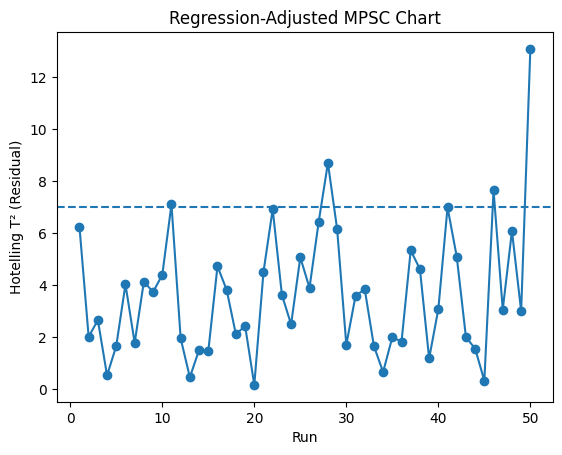

In [ ]:
# Plot Residual-Based T² Chart

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["T2_residual"], marker="o")
plt.axhline(7, linestyle="--")   # illustrative control limit
plt.xlabel("Run")
plt.ylabel("Hotelling T² (Residual)")
plt.title("Regression-Adjusted MPSC Chart")
plt.show()

# INTERPRETASI ENGINEERING (INI YANG PENTING)

# Tanpa regression adjustment
# T² naik saat:
# temperature naik
# tool makin aus
# Engineer bingung:
# “Ini masalah atau normal?”

# Dengan regression adjustment
# T² residual:
# stabil selama pengaruh X normal
# naik hanya jika:
# ada faktor baru
# atau proses rusak
# Kalimat kunci:
# > Kita tidak menghukum proses karena efek yang sudah kita pahami.

# kok yang di analisis bukan X atau Ynya tapi residualnya? 
# ternyata masuk akal, residual ada error prediksi, sehingga residual diarrtikan di sini adalah faktor yang tidak ada di X tapi mempengaruhi Y. 
# misal jika error besar, otomatis prediksi tersebut bukan karena X. 
# lalu supaya multiple residual bisa di visualiasi, maka lakukan T2 hotelling

# Kenapa X dan Y tidak cocok untuk monitoring langsung?
# Monitor Y langsung
# Masalah:
# Y naik → bisa karena:
# temperatur naik (normal)
# tool age (normal)
# atau kerusakan
# Engineer: “Saya tidak tahu ini harus panik atau tidak.”
# Monitor X
# Masalah:
# X sering:
# tidak bisa dikontrol penuh
# bukan indikator kualitas langsung
# X ≠ kualitas.
# Monitor residual
# Keunggulan:
# X sudah “dibersihkan”
# hanya tersisa unexpected behavior
# Kalimat penting:
# Residual adalah sinyal kualitas murni.

In [ ]:
# MULTIVARIATE SPC – LATENT METHOD (PCA)

# Kenapa kita butuh “latent method”?
# Masalah muncul ketika:
# jumlah variabel banyak
# sangat berkorelasi
# sulit diinterpretasi satu per satu
# Contoh nyata:
# 50 sensor
# 100 parameter proses
# 200 feature hasil vision system
# Ruang aslinya terlalu “ramai”.

# Intuisi PCA (tanpa rumus dulu)
# PCA menjawab pertanyaan sederhana:
# > “Arah variasi utama proses itu ke mana?”
# Alih-alih:
# monitor 50 variabel
# PCA:
# mencari beberapa arah utama (latent variables)
# Kalimat kunci:
# > PCA memutar sistem koordinat supaya variasi proses jadi terstruktur.

# Apa itu “latent variable” secara engineering?
# Latent variable BUKAN variabel baru misterius.
# Dia adalah:
# kombinasi linear variabel asli
# yang punya makna fisik tersembunyi
# Contoh interpretasi:
# PC1 → “overall tool wear”
# PC2 → “thermal effect”
# PC3 → “alignment error”
# Engineer-friendly kalau dipahami benar.

# PCA sebagai model proses normal
# Ini poin PENTING:
# > PCA bukan sekadar reduksi dimensi, tapi model proses normal.
# Proses normal:
# bergerak di subspace tertentu
# mengikuti korelasi alami
# Fault:
# keluar dari subspace
# atau bergerak aneh di dalamnya

# Dua statistik utama dalam PCA-based SPC
# Ini inti MPSC berbasis PCA.
# Hotelling T² (di latent space)
# T² PCA menjawab:
# > “Apakah skor latent masih dalam rentang normal?”
# monitor variasi terjelaskan
# sensitif ke shift sistemik
# Q-statistic (SPE – Squared Prediction Error)
# Q-stat menjawab:
# > “Apakah ada variasi yang TIDAK bisa dijelaskan oleh PCA?”
# Ini sangat penting:
# > Q-stat = residual PCA

# Kalimat emas:
# > Q-stat adalah residual versi latent space.

In [ ]:
# KONTEKS PROSES

# Proses: machining housing
# Sensor / variabel kualitas (berkorelasi):
# diameter_mm
# roundness_um
# surface_ra_um
# vibration_rms
# spindle_power_kw

# Fenomena:
# tool wear & misalignment → pola korelasi berubah
# fault kecil sering tidak terlihat univariate

# Data Sintetis (DataFrame, konteks jelas)

import numpy as np
import pandas as pd

np.random.seed(0)

n = 60
rows = []

for t in range(n):
    drift = max(0, t - 35)  0.01
    
    rows.append({
        "run": t + 1,
        "diameter_mm": 50 + 0.002t + np.random.normal(0, 0.01),
        "roundness_um": 4 + 0.1t + np.random.normal(0, 0.6),
        "surface_ra_um": 1.5 + 0.03t + np.random.normal(0, 0.15),
        "vibration_rms": 2 + 0.02t + drift + np.random.normal(0, 0.2),
        "spindle_power_kw": 5 + 0.05t + drift2 + np.random.normal(0, 0.3)
    })

df = pd.DataFrame(rows)
df.head()

,run,diameter_mm,roundness_um,surface_ra_um,vibration_rms,spindle_power_kw
0,1,50.017641,4.240094,1.646811,2.448179,5.560267
1,2,49.992227,4.670053,1.507296,1.999356,5.173180
2,3,50.005440,5.072564,1.674156,2.064335,5.233159
3,4,50.009337,5.196447,1.559226,2.122614,4.893771
4,5,49.982470,4.792171,1.749665,1.931567,5.880926


In [35]:
# Standariasi dan Modeling PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    "diameter_mm", "roundness_um", "surface_ra_um",
    "vibration_rms", "spindle_power_kw"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.iloc[:35])  # Phase I (normal)

pca = PCA(n_components=2)  # latent dimension
pca.fit(X_scaled)

PCA(n_components=2)

In [37]:
# Skor PCA (Variabel Laten)

scores = pca.transform(scaler.transform(X))
scores_df = pd.DataFrame(scores, columns=["PC1", "PC2"])

# Interpretasi:
# PC1 → dominant variation (tool wear + power)
# PC2 → secondary effect (geometry + vibration)

In [38]:
# Hotelling T^2 (Latent Space)

Lambda_inv = np.linalg.inv(np.diag(pca.explained_variance_))

T2 = []
for t in scores:
    T2.append(t.T @ Lambda_inv @ t)

df["T2_PCA"] = T2

In [ ]:
# Q-Statistic (Residual / SPE)

X_hat = pca.inverse_transform(scores)
X_scaled_full = scaler.transform(X)

Q = np.sum((X_scaled_full - X_hat)2, axis=1)
df["Q_stat"] = Q

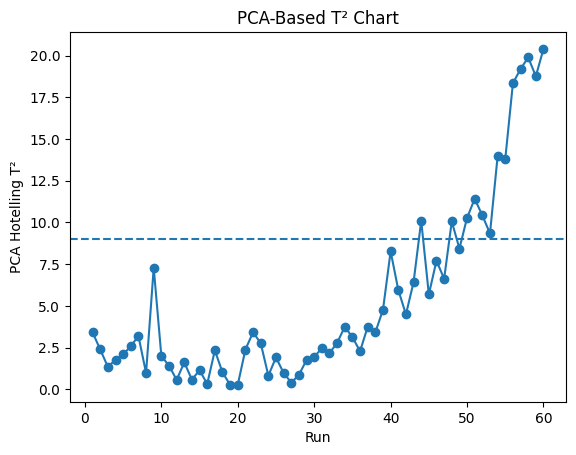

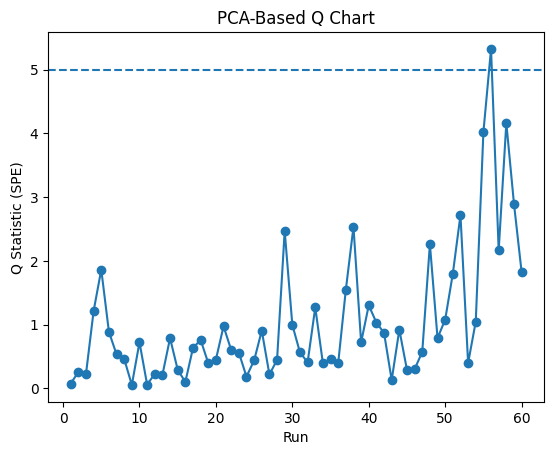

In [ ]:
# Plot PCA control charts

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["T2_PCA"], marker="o")
plt.axhline(9, linestyle="--")   # illustrative limit
plt.xlabel("Run")
plt.ylabel("PCA Hotelling T²")
plt.title("PCA-Based T² Chart")
plt.show()

plt.figure()
plt.plot(df["run"], df["Q_stat"], marker="o")
plt.axhline(5, linestyle="--")   # illustrative limit
plt.xlabel("Run")
plt.ylabel("Q Statistic (SPE)")
plt.title("PCA-Based Q Chart")
plt.show()

# INTERPRETASI ENGINEERING (INI YANG PENTING)

# T² PCA naik
# Artinya:
# Pola variasi utama proses bergeser,
# tapi masih mengikuti korelasi normal.
# Contoh:
# tool wear sistemik
# thermal expansion global

# Q-Statistic naik
# Artinya:
# Ada perilaku yang TIDAK bisa dijelaskan oleh model normal.
# Contoh:
# misalignment lokal
# bearing defect
# sensor error
# Kalimat emas:
# Q adalah residual PCA.

In [ ]:
#  MPSC – LATENT METHOD (PLS)

# Kenapa PCA “belum cukup” di banyak proses industri?
# PCA menjawab:
# > “Di mana variasi terbesar data berada?”
# Masalahnya: variasi terbesar belum tentu penting untuk kualitas, sensor bisa sangat variatif tapi tidak relevan ke CTQ
# Contoh nyata: getaran tinggi tapi tidak pengaruhi diameter, noise sensor besar tapi tidak critical
# PCA bisa “sibuk” memodelkan hal yang tidak penting secara kualitas.

#  Intuisi PLS (tanpa rumus dulu)
# PLS menjawab pertanyaan berbeda:
# > “Variasi X mana yang PALING menjelaskan Y?”
# Bukan: variasi terbesar. Tapi: variasi paling relevan
# Kalimat kunci:
# > PLS memutar ruang X supaya paling sejalan dengan kualitas (Y).

# Struktur dasar PLS (konseptual)
# PLS bekerja dengan:
# X-space (sensor, process variables)
# Y-space (quality variables)
# PLS mencari:
# latent variable X (T)
# latent variable Y (U)
# yang:
# saling berkorelasi maksimum
# Ini supervised latent method.

# PLS sebagai model proses normal
# Sama seperti PCA:
# PLS membangun model normal
# tapi sekarang:
# “normal” didefinisikan oleh hubungan X → Y
# Ini sangat cocok untuk:
# proses yang sudah dipahami
# quality-driven monitoring

# Statistik monitoring dalam PLS-MSPC
# Dalam praktik MPSC berbasis PLS, ada 3 komponen penting:-
# 1. T² pada latent X (T²ₓ)
# Menjawab:
# > “Apakah kondisi proses masih berada di ruang operasi normal?”
# monitoring process state
# mirip PCA T², tapi diarahkan ke kualitas
# 2. T² pada latent Y (T²ᵧ)
# Menjawab:
# > “Apakah kualitas bergerak abnormal?”
# lebih jarang dipakai
# tapi berguna untuk diagnosis
# 3. Q-statistic (Residual)
# Ini yang paling penting.
# PLS residual:
# X-residual (Qₓ) → perilaku sensor aneh
# Y-residual (Qᵧ) → kualitas tidak sesuai prediksi
# Kalimat emas:
# > PLS memisahkan ‘process abnormality’ dan ‘quality abnormality’.

# Hubungan PLS dengan regression-adjusted MPSC
# Sekarang hubungkan ke aha moment Anda sebelumnya.
# Regression-adjusted MPSC:
# X → Y
# residual Y dimonitor
# PLS-based MSPC:
# X → Y
# residual X & residual Y dimonitor
# tapi:
# X di-compress
# Y di-compress
# PLS = regression + PCA sekaligus.

# Kapan PLS lebih tepat daripada PCA?
# | Kondisi proses            | Pilihan |
# | ------------------------- | ------- |
# | Banyak sensor, CTQ jelas  | PLS     |
# | Eksplorasi awal           | PCA     |
# | Kualitas jadi fokus utama | PLS     |
# | Tidak ada Y               | PCA     |
# | Closed-loop EPC           | PLS     |

# PLS & diagnosis (ini nilai tambah)
# PLS memungkinkan:
# contribution plot ke X
# kontribusi sensor ke fault
# tracing ke CTQ
# Ini kenapa PLS:
# sangat disukai di chemical & semiconductor
# cocok untuk advanced process control

In [ ]:
# IMPLEMENTASI

# MPSC – PLS (Partial Least Squares)

# KONTEKS PROSES (REAL & MASUK AKAL)
# Proses: machining precision part
# Process variables (X – banyak sensor)
# `spindle_speed_rpm`
# `feed_rate_mm_min`
# `vibration_rms`
# `spindle_power_kw`
# `coolant_temp_C`
# Quality variables (Y – CTQ)
# `diameter_mm`
# `roundness_um`
# `surface_ra_um`

# Data Sintetis (DataFrame)

import numpy as np
import pandas as pd

np.random.seed(1)
n = 60
rows = []

for t in range(n):
    tool_wear = max(0, t - 35)  0.02
    
    X = {
        "spindle_speed_rpm": 6000 + np.random.normal(0, 80),
        "feed_rate_mm_min": 250 + np.random.normal(0, 5),
        "vibration_rms": 2.5 + tool_wear + np.random.normal(0, 0.2),
        "spindle_power_kw": 6 + tool_wear1.5 + np.random.normal(0, 0.3),
        "coolant_temp_C": 22 + np.random.normal(0, 0.4),
    }
    
    Y = {
        "diameter_mm": 50 + 0.002X["coolant_temp_C"] + tool_wear0.01 + np.random.normal(0, 0.01),
        "roundness_um": 4 + 0.5X["vibration_rms"] + np.random.normal(0, 0.3),
        "surface_ra_um": 1.4 + 0.2X["vibration_rms"] + np.random.normal(0, 0.12),
    }
    
    rows.append({{"run": t+1}, X, Y})

df = pd.DataFrame(rows)
df.head()

,run,spindle_speed_rpm,feed_rate_mm_min,vibration_rms,spindle_power_kw,coolant_temp_C,diameter_mm,roundness_um,surface_ra_um
0,1,6129.947629,246.941218,2.394366,5.678109,22.346163,50.021677,5.720626,1.787528
1,2,6025.523128,248.753148,2.792422,5.381958,21.871033,50.039902,5.736342,1.826497
2,3,5986.205743,245.610708,2.508443,6.174845,21.559752,50.054567,5.524699,1.961988
3,4,6072.068476,246.581361,2.475422,5.719269,21.892845,50.049089,5.030213,1.847474
4,5,5945.026184,245.773972,2.365751,5.996201,21.553076,50.045450,5.680816,1.962195


In [21]:
# Phase I – Scaling & PLS Model

from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

X_cols = [
    "spindle_speed_rpm", "feed_rate_mm_min",
    "vibration_rms", "spindle_power_kw", "coolant_temp_C"
]

Y_cols = ["diameter_mm", "roundness_um", "surface_ra_um"]

# Phase I (normal)
X_train = df.iloc[:35][X_cols]
Y_train = df.iloc[:35][Y_cols]

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

Xs = scaler_X.fit_transform(X_train)
Ys = scaler_Y.fit_transform(Y_train)

pls = PLSRegression(n_components=2)
pls.fit(Xs, Ys)

PLSRegression()

In [22]:
# Latent Scores (T & U)

Xs_all = scaler_X.transform(df[X_cols])
Ys_all = scaler_Y.transform(df[Y_cols])

T = pls.transform(Xs_all)          # latent X
U = Ys_all @ pls.y_weights_        # latent Y (manual)

In [24]:
# Hotelling T² – Latent X (Process Monitoring)

import numpy as np

cov_T = np.cov(T[:35].T)
cov_T_inv = np.linalg.inv(cov_T)

T2_X = []
for t in T:
    T2_X.append(t.T @ cov_T_inv @ t)

df["T2_X"] = T2_X

# Interpretasi engineering
# T²ₓ naik → kondisi proses (sensor) keluar dari ruang operasi normal
# contoh: vibration + power meningkat bersamaan → tool wear sistemik

In [25]:
# Hotelling T² – Latent Y (Diagnosis Quality)

cov_U = np.cov(U[:35].T)
cov_U_inv = np.linalg.inv(cov_U)

T2_Y = []
for u in U:
    T2_Y.append(u.T @ cov_U_inv @ u)

df["T2_Y"] = T2_Y

# Interpretasi engineering
# T²ᵧ tinggi → kualitas menyimpang signifikan
# cocok untuk diagnosis, bukan alarm utama

In [ ]:
# Q-statistic X (Residual Sensor Space)

X_hat = pls.inverse_transform(pls.transform(Xs_all))
Q_X = np.sum((Xs_all - X_hat)2, axis=1)

df["Q_X"] = Q_X

# Interpretasi engineering
# Qₓ tinggi → sensor berperilaku tidak sesuai model normal
# contoh: sensor rusak, misalignment lokal


# Q-statistic Y (Residual Quality)

Y_hat = pls.predict(Xs_all)
Q_Y = np.sum((Ys_all - Y_hat)2, axis=1)

df["Q_Y"] = Q_Y

# Interpretasi engineering
# Qᵧ tinggi → kualitas tidak sesuai prediksi meskipun proses terlihat normal
# contoh: material issue, hidden defect

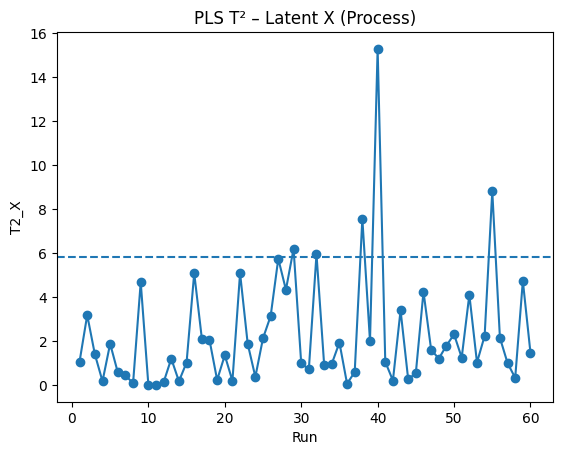

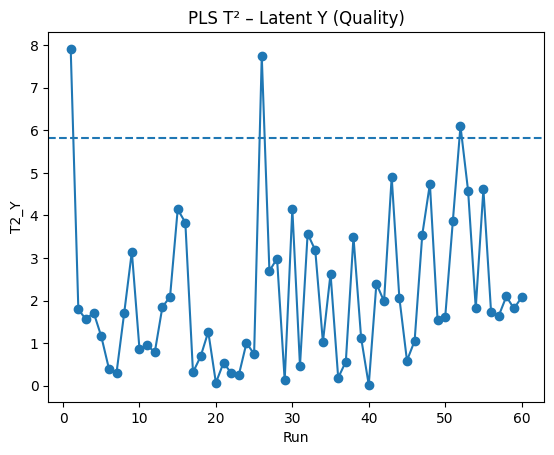

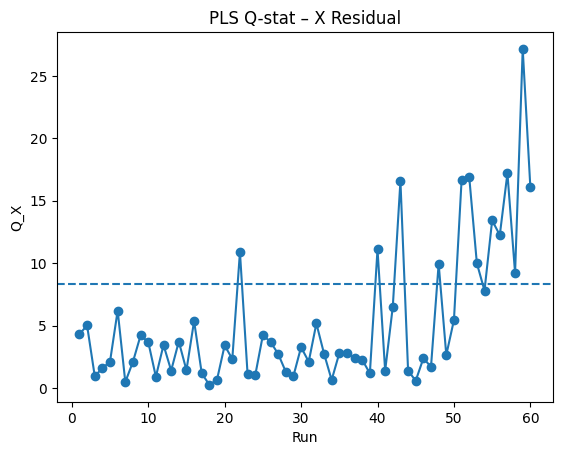

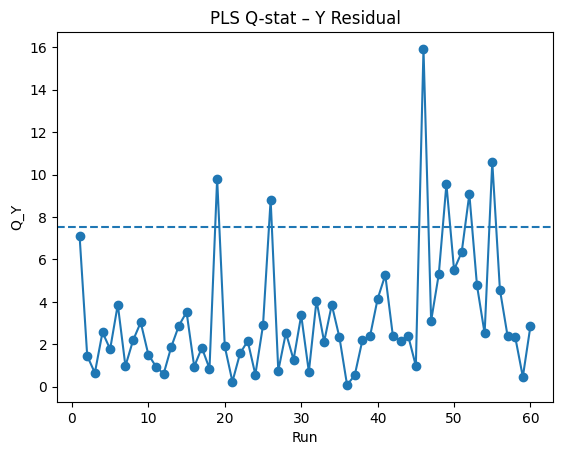

In [ ]:
# Plot Monitoring Charts

import matplotlib.pyplot as plt

for col, title in [
    ("T2_X", "PLS T² – Latent X (Process)"),
    ("T2_Y", "PLS T² – Latent Y (Quality)"),
    ("Q_X", "PLS Q-stat – X Residual"),
    ("Q_Y", "PLS Q-stat – Y Residual"),
]:
    plt.figure()
    plt.plot(df["run"], df[col], marker="o")
    plt.axhline(df[col][:35].mean()3, linestyle="--")  # ilustratif
    plt.title(title)
    plt.xlabel("Run")
    plt.ylabel(col)
    plt.show()

# INTERPRETASI ENGINEERING (INI INTI NILAINYA)
# Kombinasi diagnosis PLS-MSPC:
# | Pola             | Makna                  |
# | ---------------- | ---------------------- |
# | T²ₓ ↑, Qₓ normal | Drift sistemik proses  |
# | T²ₓ ↑, Qₓ ↑      | Sensor/process fault   |
# | T²ᵧ ↑, Qᵧ ↑      | Quality issue nyata    |
# | T²ₓ normal, Qᵧ ↑ | Hidden quality problem |
# Ini jauh lebih informatif daripada PCA saja.

In [ ]:
# Kalimat kunci:
# Contribution plot = “kenapa alarm ini terjadi?”
# Analogi yang PAS (biar klik)
# Bayangkan:
#tree importance:
# “Sensor getaran penting secara umum”
# contribution plot:
# “Alarm ini 60% karena getaran, 25% power, 10% coolant”
# Sangat beda niat.

In [ ]:
# IMPLEMENTASI

# Contribution Plot – PLS-MSPC
# Contribution Plot untuk T²ₓ (Process State)

# Konsep
# T²ₓ:
# T^2 = \mathbf{t}^T \Sigma_T^{-1} \mathbf{t}
# Contribution tiap variabel X ≈ berapa besar variabel itu mendorong skor latent menjauh dari nol

# Kode Contribution T²ₓ

# loading matrix (X space)
P = pls.x_loadings_   # shape: (p_X, n_components)

# covariance inverse latent
Sigma_T_inv = np.linalg.inv(np.cov(T[:35].T))

# pilih satu titik alarm (misal run ke-50)
i = 49
t_i = T[i]

# contribution per X variable
T2_contrib_X = []

for j in range(P.shape[0]):
    p_j = P[j, :]
    contrib = (t_i @ Sigma_T_inv @ p_j)2
    T2_contrib_X.append(contrib)

T2_contrib_X = np.array(T2_contrib_X)
T2_contrib_X = T2_contrib_X / T2_contrib_X.sum()  # normalisasi

contrib_T2X_df = pd.DataFrame({
    "variable": X_cols,
    "T2_X_contribution": T2_contrib_X
})

contrib_T2X_df

# Interpretasi Engineering
# Contoh:
# > Jika `vibration_rms` kontribusinya 55%
# > → pergeseran proses terutama disebabkan getaran
# Ini:
# lokal
# spesifik alarm
# bukan ranking global

,variable,T2_X_contribution
0,spindle_speed_rpm,0.149479
1,feed_rate_mm_min,0.000012
2,vibration_rms,0.096162
3,spindle_power_kw,0.004234
4,coolant_temp_C,0.750112


In [ ]:
# Contribution Plot untuk Qᵧ (Quality Residual)

# residual Y
Y_hat_scaled = Y_hat
Y_residual = Ys_all - Y_hat_scaled

Qy_contrib = Y_residual[i]2
Qy_contrib = Qy_contrib / Qy_contrib.sum()

contrib_QY_df = pd.DataFrame({
    "variable": Y_cols,
    "Q_Y_contribution": Qy_contrib
})

contrib_QY_df

# Interpretasi Engineering
# > Kualitas mana yang tidak sesuai prediksi proses
# Misal:
# `roundness_um` dominan → mechanical alignment issue

,variable,Q_Y_contribution
0,diameter_mm,0.067883
1,roundness_um,0.006274
2,surface_ra_um,0.925843


In [ ]:
# Cara paling WARAS untuk PLS Q-stat

# Ambil Qₓ / Qᵧ Phase I
# Tentukan percentile (95% / 99%)

Qx_limit = np.percentile(df["Q_X"][:35], 99)
Qy_limit = np.percentile(df["Q_Y"][:35], 99)

# Engineering justification:
# > “Ini adalah batas variasi residual normal yang pernah terjadi.”

In [ ]:
# MSPC → Independent Component Analysis (ICA)

# Posisi ICA di MSPC (kenapa muncul)
# ICA muncul karena keterbatasan PCA / PLS.
# Recall:
# PCA: cari arah variasi maksimum (orthogonal)
# PLS: cari arah variasi X yang relevan ke Y
# Masalahnya:
# > Variasi maksimum ≠ variasi yang menyebabkan masalah
# ICA mencoba menjawab:
# > “Apa sumber fisik independen di balik sinyal multivariat ini?”

# Ide dasar ICA (sangat intuitif)
3CICA berangkat dari asumsi proses nyata:
# > Proses manufaktur sering dipengaruhi oleh beberapa sumber gangguan independen, misalnya:
# tool wear
# misalignment
# thermal drift
# vibration mode
# material batch effect
# Masing-masing sumber:
# tidak saling bergantung
# bercampur secara linear di sensor
# Sensor yang kita ukur = campuran.
# Secara matematis (ringan):
# \mathbf{X} = \mathbf{A} \mathbf{S}]
# X → data sensor (observed)
# S → sumber independen (latent physical causes)
# A → mixing matrix
# ICA ingin:
# \mathbf{S} = \mathbf{W} \mathbf{X}

# Bedanya ICA vs PCA (INI KUNCI)
# | Aspek              | PCA               | ICA                        |
# | ------------------ | ----------------- | -------------------------- |
# | Tujuan             | Variance maksimum | Independensi statistik     |
# | Asumsi             | Gaussian          | Non-Gaussian               |
# | Orthogonal         | Ya                | Tidak wajib                |
# | Urutan komponen    | Jelas             | Tidak ada urutan           |
# | Interpretasi fisik | Lemah             | Lebih kuat (kadang)        |
# Kalimat penting:
# > PCA memutar data supaya varians besar terlihat,
# > ICA memutar data supaya sumber gangguan terpisah.

# Kenapa ICA menarik untuk MSPC?
# Karena di MSPC kita ingin:
# deteksi fault
# isolasi penyebab
# bukan sekadar reduksi dimensi
# ICA:
# bisa memisahkan fault mode
# bagus untuk:
# vibration
# acoustic
# energy signal
#  sensor campuran

# Tapi kenapa ICA jarang dipakai di SPC klasik?
# Ini penting dan jujur.
# Alasan praktis:
# Tidak ada urutan komponen
# PC1, PC2 jelas
# IC1, IC2 tidak ada ranking
# Lebih sensitif noise
# butuh preprocessing bagus
# Interpretasi tidak selalu stabil
# tanda komponen bisa flip
# skala tidak unik
# Lebih riset daripada SOP
# Makanya ICA:
# > lebih sering dipakai di riset fault diagnosis, bukan SPC shopfloor.

# ICA di MSPC biasanya dipakai bagaimana?
# Bukan menggantikan PCA, tapi:
# Pola sehat:
# PCA / PLS → monitoring global
# ICA → fault isolation
# ICA sering:
# dipakai setelah alarm
# bukan primary detector

# Statistik monitoring pada ICA
# Biasanya:
# monitor independent component score
# pakai:
# T² pada IC
#  atau residual reconstruction error
# Tapi:
# distribusi IC tidak Gaussian
# threshold → empirical / percentile
# Ini selaras dengan prinsip Anda:
# > fokus tren, bukan limit keras

# Hubungan ICA dengan ML (biar nyambung)
# ICA itu:
# salah satu unsupervised source separation
# ancestor dari:
# sparse coding
# autoencoder (konseptual)
# representation learning
# Makanya Anda merasa:
# > “ini kok ML banget”
# Betul.

# Kapan ICA masuk akal dipakai?
# ICA masuk akal jika:
# sinyal non-Gaussian
# campuran sumber fisik
# sensor banyak & redundant
# tujuan diagnosis, bukan compliance
# ICA kurang cocok jika:
# data kecil
# noise tinggi
# hanya butuh alarm sederhana

In [ ]:
# Analogi ICA
# misal ada 3 orang bernyanyi bersamaan dan direkam suara(1 file)
# nah hasil rekaman suara itu pasti gak jelas karena 3 orang nyanyi bersamaan
# jadi ICA bisa memisahkan 3 suara yang dijadikan 1 bercampur itu menjadi terpisah(independent)
# sehingga mudah dilakukan analisa

# misal lagi:
# mesin ada 3 suara, yaitu suara bearing, getaran, dan suara proses
# ICA butuh minimal jumlah sensor ≥ jumlah sumber
# Jadi contoh paling aman:
# 3 sumber suara
# ≥3 sensor (misalnya 3 microphone di posisi berbeda)
# tiap sensor merekam campuran berbeda
# otomatis data suara bearing tercampur suara getaran dan suara proses
# begitu juga suara getaran tercampur suara bearing dan suara proses
# maka ICA bisa membersihkan suara bearing itu supaya tidak tercampur lagi suara getaran dan proses, sehingga enak untuk di analisa

# ICA bekerja dengan memutar ruang data berdimensi tinggi sehingga 
# setiap komponen laten menjadi saling independen secara statistik, 
# yang memungkinkan pemisahan sumber fisik yang tercampur dalam pengukuran sensor.

In [ ]:
# IMPLEMENTASI

# MSPC → Independent Component Analysis (ICA)

# KONTEKS PROSES
# Proses: machining precision component
# Masalah realistis:
# thermal drift
# tool wear
# vibration fault
# Semua bercampur di sensor → cocok untuk ICA.

# Generate Data (Sensor Campuran)

import numpy as np
import pandas as pd

np.random.seed(42)
n = 120
rows = []

for t in range(n):
    thermal = 0.03  t
    wear = max(0, t - 60)  0.05
    vibration_fault = 2 if 80 <= t <= 90 else 0

    rows.append({
        "run": t+1,
        "spindle_power": 5 + thermal + wear + np.random.normal(0, 0.3),
        "vibration_rms": 2 + wear + vibration_fault + np.random.normal(0, 0.2),
        "acoustic_emission": 3 + vibration_fault + np.random.normal(0, 0.4),
        "motor_temp": 40 + thermal + np.random.normal(0, 0.5),
    })

df = pd.DataFrame(rows)
df.head()

# Sensor-sensor ini bukan independen → campuran efek fisik.

,run,spindle_power,vibration_rms,acoustic_emission,motor_temp
0,1,5.149014,1.972347,3.259075,40.761515
1,2,4.959754,1.953173,3.631685,40.413717
2,3,4.919158,2.108512,2.814633,39.827135
3,4,5.162589,1.617344,2.310033,39.808856
4,5,4.816151,2.062849,2.636790,39.413848


In [2]:
# Scaling & ICA Decomposition

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA

X_cols = ["spindle_power", "vibration_rms", "acoustic_emission", "motor_temp"]

scaler = StandardScaler()
Xs = scaler.fit_transform(df[X_cols])

ica = FastICA(n_components=3, random_state=1)
S = ica.fit_transform(Xs)   # Independent components
A = ica.mixing_             # Mixing matrix

IC_df = pd.DataFrame(S, columns=["IC1", "IC2", "IC3"])
df = pd.concat([df, IC_df], axis=1)

# Makna engineering
# `IC1`, `IC2`, `IC3` ≈ hidden physical sources
# urutan tidak penting
# tanda (+/-) tidak penting

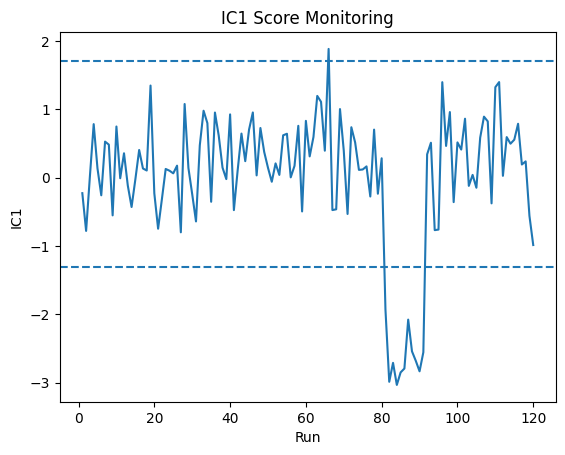

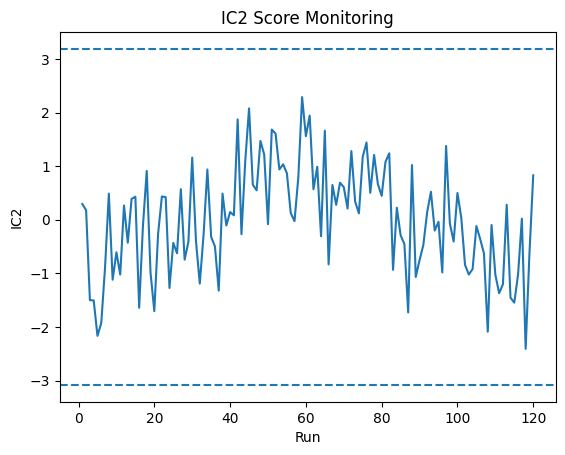

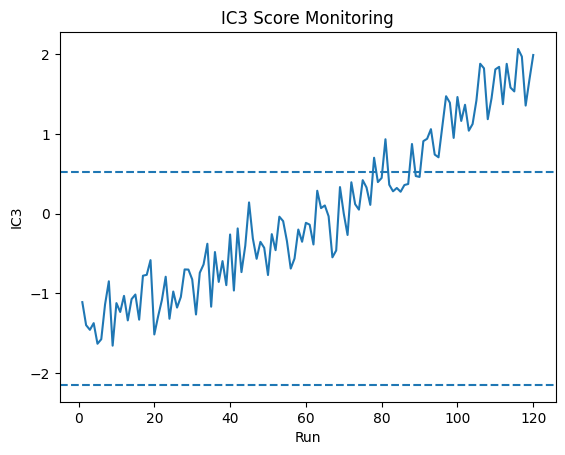

In [ ]:
# IC Score Monitoring (Trend-Based)

import matplotlib.pyplot as plt

for ic in ["IC1", "IC2", "IC3"]:
    plt.figure()
    plt.plot(df["run"], df[ic])
    plt.axhline(df[ic][:60].mean() + 3df[ic][:60].std(), linestyle="--")
    plt.axhline(df[ic][:60].mean() - 3df[ic][:60].std(), linestyle="--")
    plt.title(f"{ic} Score Monitoring")
    plt.xlabel("Run")
    plt.ylabel(ic)
    plt.show()

# Interpretasi engineering
# lonjakan IC ≠ “out of control”
# lonjakan IC → satu sumber fisik aktif
# contoh:
# IC2 spike di run 80–90 → vibration fault

In [5]:
# ICA-based T² (Optional, tetap kita hitung)

cov_IC = np.cov(S[:60].T)
cov_IC_inv = np.linalg.inv(cov_IC)

T2_ICA = []
for s in S:
    T2_ICA.append(s.T @ cov_IC_inv @ s)

df["T2_ICA"] = T2_ICA

# Interpretasi
# T² ICA = agregat energi fault
# bagus untuk summary view
# diagnosis tetap di IC individual

In [ ]:
# Reconstruction Error (Q-stat ICA)

X_hat = S @ A.T
Q_ICA = np.sum((Xs - X_hat)2, axis=1)

df["Q_ICA"] = Q_ICA

# Makna engineering
# Q_ICA tinggi → fenomena di luar sumber normal
# sensor glitch / unknown fault mode

In [9]:
# Threshold (Tetap Ada, Tapi Secondary)

T2_limit = np.percentile(df["T2_ICA"][:60], 99)
Q_limit = np.percentile(df["Q_ICA"][:60], 99)

In [ ]:
#  MSPC → Kesadaran Time Series

# Dynamic Principal Component Analysis (DPCA)
# Ini materi yang sangat penting, karena 90% data proses itu time-dependent, tapi SPC klasik menganggap i.i.d.

# Masalah utama MSPC klasik
# PCA / ICA / PLS standar mengasumsikan:
# > setiap observasi independen antar waktu
# Padahal di proses nyata:
# temperatur → punya inertia
# wear → akumulatif
# flow → delay
# control loop → feedback

# Data autocorrelated.
# Akibatnya:
# PCA “terlihat” fault padahal hanya dinamika normal
# T²/Q jadi sering spike palsu

# Ide inti DPCA (sederhana tapi powerful)
# DPCA tidak mengubah PCA-nya.
# Yang diubah adalah cara membentuk data.
# Kita memperluas vektor observasi dengan lag waktu.
# Contoh sederhana
# Sensor:
# x(t)
# DPCA pakai:
# [x(t), x(t−1), x(t−2), …]
# Kalau banyak sensor:
# [x1(t), x1(t−1), x2(t), x2(t−1), …]
# PCA melihat struktur temporal, bukan snapshot.

# Analogi yang tepat (engineering)
# PCA biasa → foto
# DPCA → video pendek
# DPCA:
# > “Apakah urutan gerakan ini normal?”
# bukan:
# > “Apakah posisi ini normal?”
# Kenapa DPCA penting untuk MSPC?
# Karena:
# drift = pola, bukan titik
# fault = perubahan dinamika
# control loop → efek tertunda
# DPCA bisa:
# bedakan ramp normal vs fault
# bedakan oscillation normal vs instabilitas

# DPCA vs Time Series Model (AR, VAR)
# DPCA bukan AR/VAR.
# | Aspek           | DPCA        | AR/VAR       |
# | --------------- | ----------- | ------------ |
# | Tujuan          | Monitoring  | Prediction   |
# | Model eksplisit | Tidak       | Ya           |
# | Parameter       | PCA loading | Coefficients |
# | Robust          | Tinggi      | Sensitif     |
# DPCA:
# > monitor pola tanpa harus memodelkan dinamika eksplisit
# Cocok dengan prinsip Anda.

# Statistik monitoring pada DPCA
# Sama seperti PCA:
# T²
# Q-stat
# Tapi sekarang:
# skor mewakili trajektori pendek
# Q = pola waktu yang tidak biasa
# Threshold:
# tetap Mudholkar / empirical
# tapi lebih stabil dibanding PCA statik

# Kapan DPCA lebih baik dari PCA?
# DPCA unggul jika:
# strong autocorrelation
# slow drift
# delay antar variabel
# closed-loop control
# DPCA kurang cocok jika:
# data sparse
# event jarang
# sampling tidak konsisten

# Posisi DPCA di workflow MSPC Anda
#Workflow matang:
"""
SPC klasik
   ↓
PCA / PLS
   ↓
DPCA  ← (kalau ada autocorrelation)
   ↓
ICA (diagnosis)
"""
#CDPCA bukan pengganti, tapi penambahan kesadaran waktu.

In [ ]:
# Prinsip UMUM (yang Anda tangkap sudah benar)
# Pernyataan inti Anda:
# “model ML (scikit-learn atau bukan) tidak native time series, maka solusinya adalah preprocessing agar model paham urutan waktu”
# BENAR
# Mayoritas model ML klasik:
# melihat data sebagai baris independen
# tidak tahu baris ke-t datang setelah ke-(t−1)
# Jadi satu-satunya cara:
# bawa informasi waktu ke dalam fitur
# Inilah prinsip universalnya (ingat ini)
# Jika model tidak sadar waktu, maka waktu harus di-embed ke data.
# Cara embed:
# lag features
# rolling window
# differencing
# temporal stacking
# DPCA, Dynamic PLS, bahkan LSTM semua berangkat dari ini
# (hanya beda cara & kompleksitas).
# Dynamic PCA = PCA + time embedding
# Seperti yang kita lakukan:
# x(t) → [x(t), x(t−1), x(t−2)]
# PCA:
# tidak tahu ini time series
# tapi melihat struktur lag
# jadi sadar dinamika.
#  Dynamic PLS = PLS + time embedding (SAMA PRINSIPNYA)
# Dynamic PLS:
# X_dyn(t) = [X(t), X(t−1), X(t−2)]
# Y_dyn(t) = [Y(t), Y(t−1)]   (opsional)
# PLS:
# tetap regresi linear
# tetap latent
# tapi sekarang hubungan X–Y adalah hubungan DINAMIK
# Kenapa Dynamic PLS itu powerful di MSPC?
# Karena:
# proses nyata punya delay
# quality hari ini ≠ sensor hari ini saja
# ada inertia & transport delay
# Dynamic PLS bisa:
# memodelkan cause-effect tertunda
# memisahkan:
# fault proses
# fault dinamika

# JADI TIDAK PERLU CODE

In [ ]:
# MSPC → Canonical Variate Analysis (CVA)
# CVA ini sangat penting karena:
# dia time-series aware
# lebih “engineering” daripada kedengarannya
# dan sering dipakai di process monitoring tingkat lanjut

# Posisi CVA dalam keluarga MSPC
# Mari kita tempatkan dulu CVA di peta besar:
"""
PCA          → snapshot
DPCA         → time embedding
PLS          → X → Y relation
Dynamic PLS  → dynamic X → Y
CVA          → dynamic state monitoring
"""
# CVA adalah metode STATE-SPACE monitoring berbasis statistik.

# Masalah yang ingin diselesaikan CVA
# Proses industri nyata:
# punya dinamika
# punya state tersembunyi
# sensor hanya melihat output dari state
# Contoh:
# suhu reaktor naik karena state energi
# kualitas buruk karena state tool wear
# vibrasi karena state mechanical looseness
# PCA / DPCA:
# melihat data
# tidak eksplisit memisahkan state vs noise
# CVA:
# > mencoba mengekstrak state internal proses dari data time series

# Intuisi CVA (sangat penting)
# CVA bekerja dengan dua jendela waktu:
# Past window (masa lalu)
# Future window (masa depan)
# Kemudian CVA bertanya:
# > “Bagian dari masa lalu mana yang paling menjelaskan masa depan?”
# Itu inti CVA.

# Struktur data CVA (konsep)
# Misal:
# `y(t)` = vektor sensor
# Bentuk:`
# Y_past(t)   = [y(t−1), y(t−2), ..., y(t−p)]
# Y_future(t)= [y(t), y(t+1), ..., y(t+f)]
# CVA mencari kombinasi linier:
# z_p = W_p^T Y_{past}, \quadz_f = W_f^T Y_{future}
# dengan tujuan:
# > z_p dan z_f paling berkorelasi

# Hubungan CVA dengan CCA (ini penting)
# Nama “Canonical Variate” datang dari Canonical Correlation Analysis (CCA).
# CVA = CCA yang diaplikasikan ke data time series.
# CCA: cari pasangan kombinasi X & Y yang paling berkorelasi
# CVA: X = masa lalu, Y = masa depan
# Makanya:
# > CVA itu CCA + time embedding

# Apa yang dihasilkan CVA?
# CVA memisahkan data menjadi
# 1. State space (canonical variates)
# bagian sistematik
# dinamis
# bisa dimonitor
# 2. Residual space
# noise
# disturbance
# fault tak terstruktur
# Mirip:
# PCA: score vs residual
# CVA: state vs innovation

# Statistik monitoring dalam CVA
# Biasanya ada dua statistik utama:
# T² statistic
# memonitor state deviation
# mirip T² di PCA
# Q statistic (SPE)
# memonitor innovation / residual
# fault baru, noise, sensor issue
# Ini cocok banget dengan prinsip Anda:
# lihat tren
# lihat lonjakan
#  threshold hanya referensi

In [11]:
# IMPLEMENTASI

# MSPC – Canonical Variate Analysis (CVA)

# Konteks Proses (Realistis)
# Proses: rotating machinery / machining
# Sensor:
# vibration
# acoustic
# motor current

# Masalah nyata:
# fault tidak instan
# perubahan perlahan tapi konsisten
# engineer ingin tahu:
#  “apakah dinamika proses masih sama?”

# CVA cocok

# Generate Data Time Series (Normal → Fault)

import numpy as np
import pandas as pd

np.random.seed(0)
n = 300
rows = []

state = np.array([0.0, 0.0])  # hidden dynamics

for t in range(n):
    # state evolution
    A = np.array([[0.9, 0.1],
                  [-0.05, 0.95]])
    
    # inject slow fault
    if t > 180:
        state += np.array([0.01, -0.015])
    
    state = A @ state + np.random.normal(0, 0.05, 2)

    rows.append({
        "run": t,
        "vibration": state[0] + np.random.normal(0, 0.1),
        "acoustic": 0.7*state[0] + 0.3*state[1] + np.random.normal(0, 0.1),
        "motor_current": state[1] + np.random.normal(0, 0.1)
    })

df = pd.DataFrame(rows)
df.head()

,run,vibration,acoustic,motor_current
0,0,0.186076,0.291834,0.206764
1,1,0.017384,0.031072,0.103162
2,2,0.118783,0.081069,0.174471
3,3,0.047588,0.137825,0.110741
4,4,0.039703,-0.042250,0.442594


In [12]:
# Bentuk Past–Future Window (INTI CVA)

p = 5   # past window
f = 3   # future window

Y = df[["vibration", "acoustic", "motor_current"]].values

Y_past, Y_future = [], []

for i in range(p, len(Y) - f):
    Y_past.append(Y[i-p:i].flatten())
    Y_future.append(Y[i:i+f].flatten())

Y_past = np.array(Y_past)
Y_future = np.array(Y_future)

# past = sejarah
# future = kelanjutan
# CVA mencari bagian masa lalu yang menjelaskan masa depan

In [13]:
# Standardisasi

from sklearn.preprocessing import StandardScaler

scaler_p = StandardScaler()
scaler_f = StandardScaler()

Yp = scaler_p.fit_transform(Y_past)
Yf = scaler_f.fit_transform(Y_future)

In [15]:
# Canonical Correlation Analysis (CVA Core)

from sklearn.cross_decomposition import CCA

n_states = 2  # jumlah state dinamis
cca = CCA(n_components=n_states)

Zp, Zf = cca.fit_transform(Yp, Yf)

# Makna engineering
# `Zp` = estimated process state
# bukan sensor
# bukan noise
# dinamika inti proses

In [16]:
# Hitung Statistik T² (STATE MONITORING)

import numpy as np

cov_Z = np.cov(Zp.T)
cov_Z_inv = np.linalg.inv(cov_Z)

T2 = [z @ cov_Z_inv @ z for z in Zp]
T2

[4.100806036696427,
 5.849106357372256,
 5.615379839274193,
 5.996400020910914,
 5.735495116876261,
 3.212636214811421,
 2.2501804262480727,
 2.0610743980920403,
 3.177741882074385,
 0.9875890520280026,
 0.9369346903637245,
 0.6682267831273372,
 0.7804259759810179,
 1.4560108397892835,
 2.4709479570190642,
 3.9886438940452797,
 3.515147266349412,
 5.8246148757329035,
 6.680675244263734,
 9.446262100734984,
 10.95978881584644,
 12.198676214328,
 6.148487521888347,
 6.380094982266211,
 3.03006286470168,
 3.9569993026127968,
 2.249954958625941,
 1.033860124418988,
 1.569271490044021,
 2.1202970671248136,
 3.9255459902243373,
 2.991594313215926,
 1.8557817317133072,
 0.9680828585347239,
 0.4258081530864777,
 1.2233899679976545,
 1.4723488733698014,
 0.2911585996153324,
 0.25450142101255296,
 0.34837391647523497,
 0.05073776660295349,
 0.0016985113895240137,
 0.1924617576932468,
 1.8714218215514211,
 1.194104272778257,
 0.6090359814852364,
 1.5314044030609157,
 3.0110316113598055,
 0.933740

In [19]:
# Hitung Q Statistic (INNOVATION / RESIDUAL)

Yf_hat = cca.predict(Yp)
Q = np.sum((Yf - Yf_hat)**2, axis=1)
Q
# Makna
# Q tinggi → perilaku baru
# misal:
# sensor drift
# disturbance eksternal
# fault non-dinamis

array([ 6.22105299,  9.94647135,  7.57613418, 11.56038507,  8.44286687,
        5.58599639,  2.28273474,  4.04929863,  4.63840861,  3.72151894,
        4.03701245,  5.0905222 ,  7.05671296,  8.43048993,  8.15506436,
        9.58228301,  9.46673192,  5.90831053,  4.04834569,  3.06131126,
        4.08235294, 12.21433373,  5.54260886,  8.01413089,  3.79050645,
        4.86448098,  5.77071372,  5.28856518,  3.86433882,  2.14036127,
        5.18251542,  7.61412895,  4.82912693,  3.00769963,  4.04996382,
        4.71292523,  7.13999831,  3.93455581,  3.72746934,  4.53886255,
        5.83827084,  5.04699047,  3.95441223,  1.60098926,  1.99994671,
        3.15037946,  3.38244094,  8.48045134,  6.15119171,  7.20491067,
        6.6982186 ,  5.93546983,  4.03281595,  4.92418804,  4.59390016,
        8.4613875 ,  2.81553389,  1.38523432,  3.24492272,  8.92079885,
        7.34480609,  6.89088724,  1.87007458,  3.05104638,  3.30067755,
        3.45859872,  3.20995541,  1.95380496,  2.3378427 ,  4.85

In [ ]:
# Simpan ke DataFrame

df_cva = df.iloc[p:len(df)-f].copy()
df_cva["T2_CVA"] = T2
df_cva["Q_CVA"] = Q

# Threshold (Referensi, Bukan Alarm)

phase1 = 120

T2_limit = np.percentile(df_cva["T2_CVA"][:phase1], 99)
Q_limit = np.percentile(df_cva["Q_CVA"][:phase1], 99)

# Interpretasi Engineering (INI INTINYA)
# T2 naik pelan & konsisten
# State proses berubah
# tool wear
# misalignment
# thermal deformation
# “Proses masih jalan, tapi cara bekerjanya sudah beda.”

# Q naik tiba-tiba
# Disturbance / abnormality
# sensor problem
# material anomaly
# operating condition change

# T² & Q naik bersamaan
# Fault serius
# model lama tidak relevan
# perlu root cause analysis

In [ ]:
# Kernel Trick MSPC
# Untuk MSPC dengan data tidak linear
# kernel trick digunakan untuk memetakan data ke ruang berdimensi lebih tinggi
# sehingga pola non-linear dapat diidentifikasi menggunakan metode linear seperti PCA, PLS, atau Support Vector Machines (SVM)
# hyperplane di ruang berdimensi tinggi ini memungkinkan pemisahan data yang tidak dapat dipisahkan secara linear di ruang asli

In [20]:
# 🛠️ IMPLEMENTASI

## MSPC – One-Class SVM (OC-SVM)

# Konteks Proses (realistis)
#Proses: machining
# Variabel sensor:
# spindle_power
# vibration_rms
# motor_temp
# Tujuan:
# > Mendeteksi ketidaknormalan pola multivariat tanpa tahu bentuk fault-nya.

# Generate Data (Phase-I normal → Phase-II drift)

import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

rows = []
wear = 0

for t in range(n):
    if t > 180:
        wear += 0.003  # slow degradation
    
    rows.append({
        "run": t+1,
        "spindle_power": 5 + wear + np.random.normal(0, 0.15),
        "vibration_rms": 2 + 1.2*wear + np.random.normal(0, 0.1),
        "motor_temp": 40 + 8*wear + np.random.normal(0, 0.3),
    })

df = pd.DataFrame(rows)
df.head()

,run,spindle_power,vibration_rms,motor_temp
0,1,5.074507,1.986174,40.194307
1,2,5.228454,1.976585,39.929759
2,3,5.236882,2.076743,39.859158
3,4,5.081384,1.953658,39.860281
4,5,5.036294,1.808672,39.482525


In [21]:
#  Phase-I vs Phase-II

phase1_end = 120

X_cols = ["spindle_power", "vibration_rms", "motor_temp"]

X_train = df.loc[:phase1_end-1, X_cols]
X_all = df[X_cols]

# Phase-I = kondisi normal
# Phase-II = monitoring

In [22]:
## 4️⃣ Scaling (WAJIB untuk OC-SVM)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_all = scaler.transform(X_all)

# OC-SVM sensitif skala → jangan skip ini

# Train OC-SVM

from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.02   # toleransi outlier saat training
)

ocsvm.fit(Xs_train)

# Makna parameter engineering
# `nu = 0.02` → ~2% data Phase-I boleh “agak aneh”
# bukan error, tapi robust terhadap noise

OneClassSVM(nu=0.02)

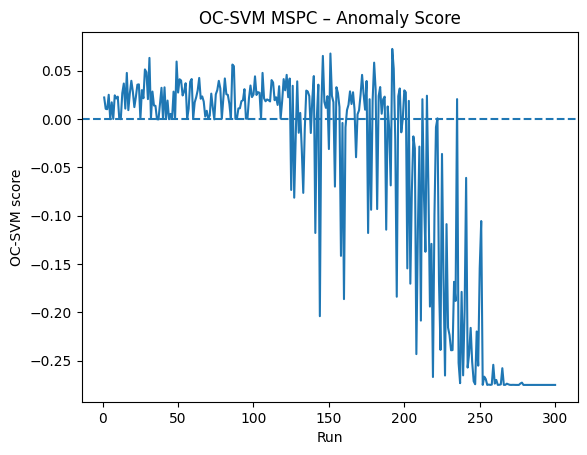

In [23]:
# Decision Function (INI YANG DIMONITOR)

score = ocsvm.decision_function(Xs_all)
df["OCSVM_score"] = score

# Interpretasi penting
# score tinggi → sangat normal
# score turun → menjauh dari normal region
# bukan klasifikasi, tapi distance-based health

# Threshold (Referensi Saja)

threshold = np.percentile(
    df.loc[:phase1_end-1, "OCSVM_score"], 1
)

# Ini bukan alarm, hanya garis bantu visual.

# Plot Monitoring (Tren yang Anda cari)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["OCSVM_score"])
plt.axhline(threshold, linestyle="--")
plt.xlabel("Run")
plt.ylabel("OC-SVM score")
plt.title("OC-SVM MSPC – Anomaly Score")
plt.show()

# Interpretasi Engineering (INI YANG PENTING)

# Score turun perlahan
# Proses drifting
# tool wear
# thermal deformation
# mechanical aging
# > “Proses masih jalan, tapi makin menjauh dari normal baseline.”

# Score drop tajam
# Abnormal event
# sensor issue
# material anomaly
# operating condition change

# Score selalu di atas threshold tapi trend turun
# Early warning terbaik
# belum “fault”
# tapi arahnya salah

In [ ]:
# Regression Adjusment
# tapi tidak pakai linear regression seperti di awal
# tapi pakai model canggih seperti random forest, SVM, boosting, atau bahkan MLP, RNN, LSTM, dan GRU

In [27]:
# Konteks Proses (realistis & masuk akal)
# Proses: machining
# X (process variables):
# spindle_speed
# feed_rate
# vibration_rms
# Y (quality / metrology):
# diameter_out (mm)
# Masalah nyata:
# hubungan X → Y tidak linear
# tool wear muncul sebagai drift residual

# Generate Data (Normal → Degradation)

import numpy as np
import pandas as pd

np.random.seed(0)
n = 250
rows = []

wear = 0

for t in range(n):
    if t > 150:
        wear += 0.002  # slow tool wear
    
    spindle_speed = 3000 + np.random.normal(0, 50)
    feed_rate = 0.25 + np.random.normal(0, 0.01)
    vibration = 1.5 + 1.2 * wear + np.random.normal(0, 0.05)

    # non-linear relationship
    diameter = (
        50
        + 0.0003 * spindle_speed
        - 0.4 * feed_rate
        + 0.2 * vibration **2
        + wear
        + np.random.normal(0, 0.01)
    )

    rows.append({
        "run": t+1,
        "spindle_speed": spindle_speed,
        "feed_rate": feed_rate,
        "vibration_rms": vibration,
        "diameter_out": diameter
    })

df = pd.DataFrame(rows)
df.head()

,run,spindle_speed,feed_rate,vibration_rms,diameter_out
0,1,3088.202617,0.254002,1.548937,51.327110
1,2,3093.377900,0.240227,1.547504,51.309363
2,3,2994.839057,0.254106,1.507202,51.265684
3,4,3038.051886,0.251217,1.522193,51.277680
4,5,3074.703954,0.247948,1.515653,51.274132


In [28]:
# Phase-I (Normal) vs Phase-II

phase1_end = 100

X_cols = ["spindle_speed", "feed_rate", "vibration_rms"]
y_col = "diameter_out"

X_train = df.loc[:phase1_end-1, X_cols]
y_train = df.loc[:phase1_end-1, y_col]

X_all = df[X_cols]
y_all = df[y_col]

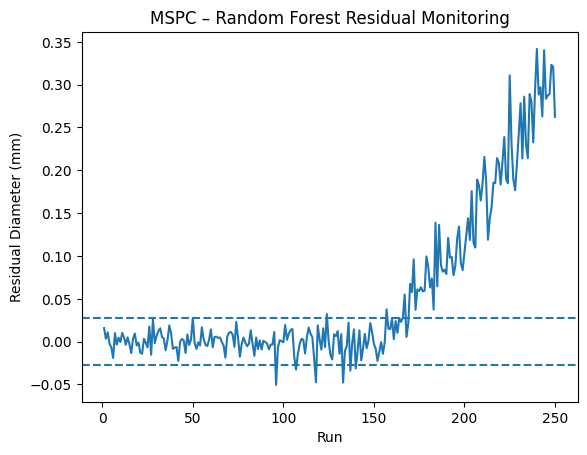

In [29]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=0
)

rf.fit(X_train, y_train)

# Hitung Residual (INI YANG DIMONITOR)

y_pred = rf.predict(X_all)
df["residual"] = y_all - y_pred

# Monitoring Statistik (Univariate dulu – cukup)

df["residual_abs"] = df["residual"].abs()

threshold = np.percentile(
    df.loc[:phase1_end-1, "residual_abs"], 99
)

# Plot Monitoring (Yang Anda Cari)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["run"], df["residual"])
plt.axhline(threshold, linestyle="--")
plt.axhline(-threshold, linestyle="--")
plt.xlabel("Run")
plt.ylabel("Residual Diameter (mm)")
plt.title("MSPC – Random Forest Residual Monitoring")
plt.show()

In [ ]:
# Kenapa nilai T² untuk residual regresi selalu positif?
# Karena Hotelling’s T² bukan residual mentah, tetapi statistik jarak kuadrat multivariat.
# Formula umum T²:
# T^2 = (\mathbf{x}-\boldsymbol{\mu})^T \, \mathbf{S}^{-1} \, (\mathbf{x}-\boldsymbol{\mu})
# Alasannya:
# ✔ T² adalah bentuk kuadrat (quadratic form).
# Hasil perkalian vektor-transpose × matriks-pos-definit × vektor
# selalu non-negatif.
# Sama seperti kuadrat z-score di univariate (misal:  tidak bisa negatif).

# ✔ Residual bisa negatif, tapi jarak kuadratnya tidak.
# Residual regresi = nilai aktual − nilai prediksi
# → bisa positif atau negatif.
# Tapi ketika membangun T² untuk monitoring residual:
# residual → dijadikan vektor
# lalu diproyeksikan dengan kovarians
# hasilnya kuadrat → tidak mungkin negatif.

# Analogi:
# Kalau tinggi kamu berbeda dari rata-rata sebesar −5 cm, selisihnya negatif.
# Tapi kalau dihitung jarak: (−5 cm)² = 25 → positif.

# Kenapa latent error (misalnya variabel laten di PCA/PLS) masuk ke T² dan Q-stat, dan kenapa juga selalu positif?
# Dalam MSPC berbasis latent variable (PCA / PLS), ada dua komponen:
# (a) Score space → Hotelling’s T²
# Mengukur apakah kombinasi utama (principal components / latent variables) masih normal.
# Score vector:
# \mathbf{t} = \mathbf{P}^T \mathbf{x}
# Lalu T² dihitung dari skor → kuadrat → selalu positif.
# Jika ada latent systematic variation (misalnya error model, drift alat, korelasi tidak tertangkap model), maka skor berubah, sehingga error masuk ke T².
# (b) Residual space → Q-statistic (SPE)
# Q atau SPE mengukur seberapa besar data tidak dijelaskan model PCA/PLS.
# Q = \| \mathbf{x} - \hat{\mathbf{x}} \|^2
# Karena Q adalah jumlah kuadrat residual, maka:
# Tidak bisa negatif.
# Semakin besar error yang terjadi di luar model, semakin besar Q.

# Kenapa latent method error bisa masuk T² dan Q?
# Ini tergantung sifat error:
# ✔ Error yang memengaruhi skor (systematic, correlated)
# → akan memengaruhi score space → masuk T².
# Contoh:
# drift sensor
# perubahan hubungan antar-variabel
# systematic shift
# ✔ Error yang tidak dijelaskan oleh model (noise, non-linear, new variation)
# → muncul di residual space → masuk Q-stat.
# Contoh:
# noise tambahan
# perubahan variansi yang tidak tertangkap PCA
# outlier unik
# Banyak jenis error akan masuk keduanya sekaligus.
# Karena sebagian variasi dapat mempengaruhi skor (systematic) dan sebagian lain tidak dijelaskan model (unsystematic), sehingga:
# T² naik
# Q naik
# Ini normal dalam MSPC.

In [ ]:
# Kenapa GMM cocok untuk MSPC clustering?
# Karena GMM:
# soft boundary
# satu titik bisa dekat ke beberapa cluster
# realistis untuk proses fisik
# Berbeda dengan K-Means:
# hard assignment
# terlalu “digital” untuk proses analog

# Peran clustering dalam MSPC (posisinya jelas)
# Clustering BUKAN pengganti:
# PCA
# CVA
# Regression residual
# Anomaly detection
# Clustering dipakai untuk:
# menemukan mode operasi
# segmentasi data

# memilih baseline MSPC yang benar
# Contoh pemakaian yang BENAR
# ✅ Benar
# “Oh, ternyata ada 3 mode operasi”
# “MSPC sebaiknya dibangun per cluster”
# “Phase-I jangan dicampur”
# Salah
# “Cluster 2 = fault”
# “Kalau pindah cluster → stop mesin”

In [ ]:
# Signal Processing
# Dalam process monitoring, signal adalah data proses yang berubah terhadap waktu, misalnya:
# temperatur mesin tiap detik, tekanan reaktor tiap menit, etc
# Secara matematis, signal = fungsi waktu, misalnya x(t)
# di MPSC sering pakai data statis, padahal proses itu dinamis
# signal processing membantu PCA dan PLS untuk mengurangi noise dan menangkap perlakuan dinamis

# Frequency Domain Analysis
# time domain: nilai sinyal berubah terhadap waktu
# contoh: getaran mesin terekam tiap detik
# frequency domain: seberapa sering sinyal itu berulang
# alih-alih bertanya "nilainya sekarang berapa?", kita bertanya "sinyal ini terdiri dari frekuensi apa saja?"
# misal mesin manufaktur, mesin berputar 3000 rpm = 50 Hz
# jika ada bearing rusak -> muncul frekuensi getaran tertentu
# transformasi time -> frekuensi
# fourier transform(FT)
# konsep: sinyal kompleks = gabungan banyak gelombang sinus
# fourier memecah sinyal menjadi: frekuensi, amplitudo, dan energi
# dalam praktik FFT(fast fourier transform dipakai)
# output utama frequency domain:
# a. amplitude spectrum -> seberapa kuat frekuensi tertentu
# b. power/energy spectrum -> energi sinyal di frekuensi tertentu
# c. dominant frequency -> frekuensi paling menonjol/berpengaruh

# Time-Frequency Domain
# Frekuensi apa muncul pada waktu tertentu?
# jadi, time domain -> kapan. frequency domain -> seberapa sering. dan time-frequency -> dua-duanya
# kenapa penting?
# karena fault sering tidak permanen, muncul sebentar lalu hilang, atau berubah secara bertahap
# contoh: chatter pada mesin miling, instabilitas sementara pada reaktor, dan sensor drifting
# frequency domain biassa tidak bisa mendeteksi ini dengan baik
# Metode utama:
# 1. Short-Time Fourier Transform (STFT)
# sinyal dipotong jadi window kecil
# output: spectogram(time vs frequency vs energy)
# trade-off: window kecil -> waktu bagus, frekuensi kasar. window besar -> frekuensi bagus, waktu kasar
# 2. Wavelet Transform (WT)
# menggunakan gelombang kecil, dan bisa menyesuaikan skala
# keunggulan: frekuensi tinggi -> resolusi waktu bagus. frekuensi rendah -> resolusi frekuensi bagus
# cocok untuk fault mendadak, perubahan lokal, dan proses non-stasioner
# fitur yang diambil dari time frquency:
# energy wavelet di level tertentu, variansi koefisien, entropy sinyal, dan statistik lokal(mean, RMS perwindow)

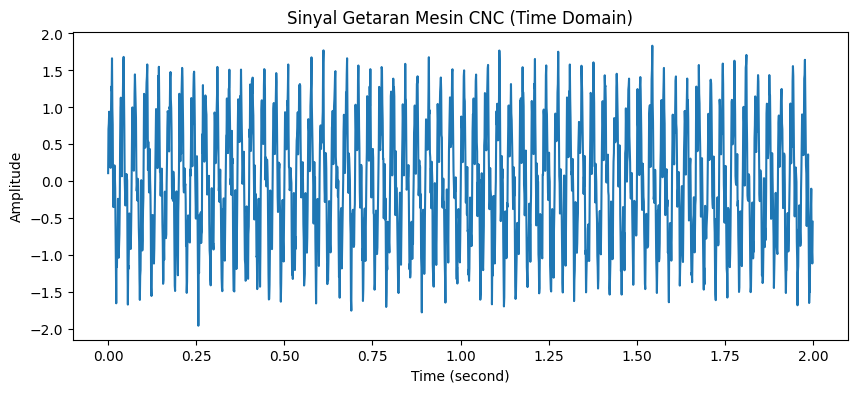

In [30]:
# Membuat Data Sinyal Sintetis

# Kita buat sinyal:
# Komponen normal: frekuensi rendah (putaran spindle)
# Komponen kerusakan: frekuensi tinggi (bearing defect)
# Noise: lingkungan pabrik


import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameter dasar sinyal
# -----------------------------
fs = 1000  # sampling frequency (Hz)
T = 2      # durasi sinyal (detik)
t = np.linspace(0, T, fs*T, endpoint=False)

# -----------------------------
# Komponen sinyal
# -----------------------------
f_spindle = 30      # Hz -> putaran spindle normal
f_bearing = 120     # Hz -> indikasi cacat bearing

signal_normal = 1.0 * np.sin(2 * np.pi * f_spindle * t)
signal_fault = 0.5 * np.sin(2 * np.pi * f_bearing * t)

noise = 0.2 * np.random.randn(len(t))

# Sinyal total
signal = signal_normal + signal_fault + noise

# -----------------------------
# Plot sinyal time domain
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(t, signal)
plt.xlabel("Time (second)")
plt.ylabel("Amplitude")
plt.title("Sinyal Getaran Mesin CNC (Time Domain)")
plt.show()

# Penjelasan angka penting
# fs = 1000 Hz
# Mesin industri biasanya sampling ≥10× frekuensi tertinggi (aturan Nyquist + margin)
# f_spindle = 30 Hz
# Misal spindle 1800 RPM → 30 putaran/detik
# f_bearing = 120 Hz
# Frekuensi cacat bearing sering kelipatan putaran utama
# noise = 0.2
# Representasi gangguan sensor, getaran lingkungan, dll

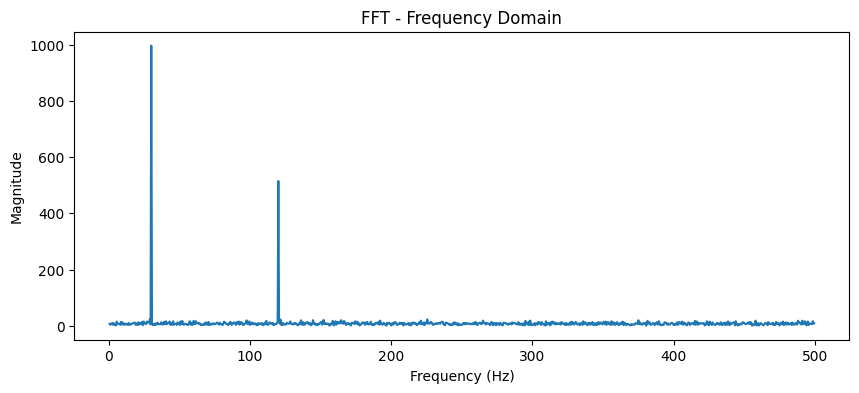

In [31]:
# Frequency Domain Analysis (FFT)
# Tujuan:
# Menjawab “frekuensi apa saja yang aktif?”
# Sangat penting untuk fault diagnosis

from scipy.fft import fft, fftfreq

# FFT
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1/fs)

# Ambil hanya frekuensi positif
idx = xf > 0

plt.figure(figsize=(10,4))
plt.plot(xf[idx], np.abs(yf[idx]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT - Frequency Domain")
plt.show()

# Interpretasi hasil
# Puncak di 30 Hz
# Operasi spindle normal
# Puncak di 120 Hz
# Indikasi fault bearing
# Amplitudo FFT = energi frekuensi
# Semakin besar → semakin serius masalah

# Dalam MSPC
# FFT → feature extraction → dipakai sebagai variabel X multivariat

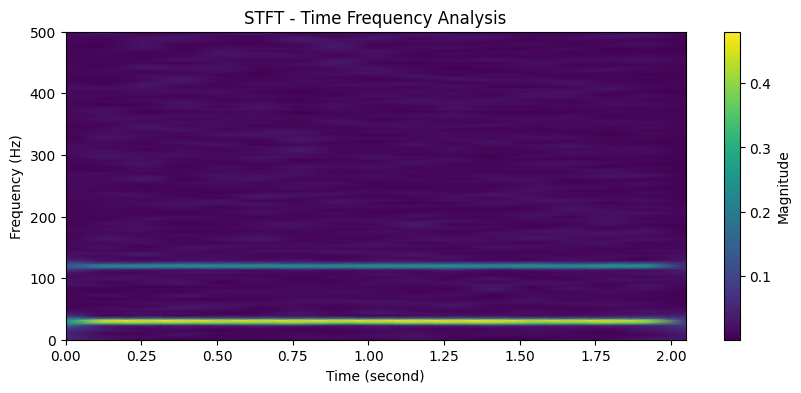

In [33]:
# Time-Frequency Domain (STFT)
# Masalah FFT:
# > FFT tidak tahu kapan frekuensi muncul
# STFT menjawab:
# > “Frekuensi ini muncul di waktu mana?”

from scipy.signal import stft

f, t_stft, Zxx = stft(signal, fs=fs, nperseg=256)

plt.figure(figsize=(10,4))
plt.pcolormesh(t_stft, f, np.abs(Zxx), shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (second)')
plt.title('STFT - Time Frequency Analysis')
plt.colorbar(label='Magnitude')
plt.show()

# Penjelasan parameter penting
# nperseg = 256
# Artinya: panjang window
# Kecil → resolusi waktu bagus, frekuensi jelek
# Besar → resolusi frekuensi bagus, waktu jelek
# Trade-off ini krusial di manufaktur

# Interpretasi industri
# Frekuensi 120 Hz muncul tidak sepanjang waktu
# Bisa artinya:
# Awal degradasi
# Beban berubah
# Pelumasan tidak stabil

In [ ]:
!pip install pyWavelets

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.2 MB 730.2 kB/s eta 0:00:06
   ------- -------------------------------- 0.8/4.2 MB 745.8 kB/s eta 0:00:05
   --------- ------------------------------ 1.0/4.2 MB 729.5 kB/s eta 0:00:05
   --------- ------------------------------ 1.0/4.2 MB 729.5 kB/s eta 0:00:05
   -------------- ------------------------- 1.6/4.2 MB 705.1 kB/s eta 0:00:04
   ----------------- ---------------------- 1.8/4.2 MB 724.5 kB/s eta 0:00:04
   ------------------- -------------------- 2.1/4.2 MB 725.0 kB/s eta 0:00:03
   ---------------------- ----------------- 2.4/4.2 MB 718.0 kB/s eta 0:00:03
   ------------------------ --------------- 2.6/4.2 MB 725.9 kB/s eta 0:00:03
   ----------------------------- ---------- 3.1/4.2 MB 726.7 kB/s eta 0:00:02
   ----------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


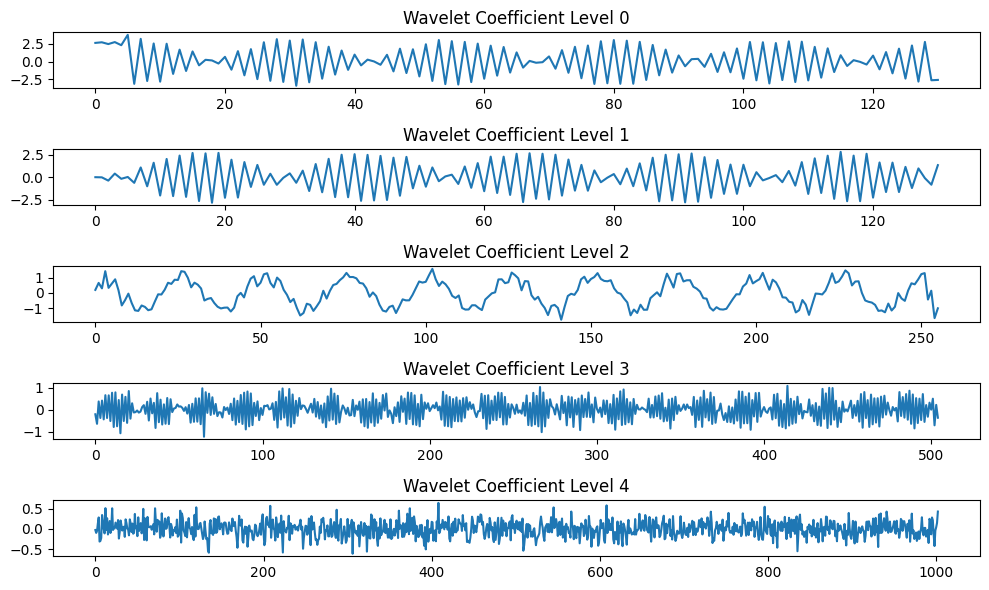

In [38]:
# Wavelet Transform (Sangat penting untuk Non-Stationary)
# Wavelet unggul saat:
# Kerusakan muncul tiba-tiba
# Sinyal tidak stasioner

import pywt

wavelet = 'db4'
coeffs = pywt.wavedec(signal, wavelet, level=4)

plt.figure(figsize=(10,6))
for i, c in enumerate(coeffs):
    plt.subplot(len(coeffs), 1, i+1)
    plt.plot(c)
    plt.title(f'Wavelet Coefficient Level {i}')
plt.tight_layout()
plt.show()

# Interpretasi
# Level rendah → frekuensi tinggi (fault)
# Level tinggi → frekuensi rendah (operasi normal)
# Lonjakan koefisien → kejadian abnormal

# Dalam MPM Wavelet → ekstraksi energi tiap level → input:
# Hotelling’s T²
# SPE / Q-statistic
# Control chart multivariat

In [ ]:
# Remaining Useful Life (RUL)
# RUL adalah perkiraan sisa waktu atau sisa siklus operasi sampai suatu aset gagal
# contoh:
# bearing diperkirakan gagal dalam 120 jam lagi
# tool pahat masih bisa dipakai 300 part lagi
# motor akan melewati batas aman dalam 15 hari
# RUL itu prediksi ke depan, bukan deteksi fault saat ini

# Estimating RUL - With Lifetime Data (Survival Models)
# jenis data:
# data yang dimiliki hanya waktu sampai gagal, tidak ada sensor detail, dan tidak tahu proses degradasi
# contoh: bearing A gagal setelah 1200 Jam, Bearing B gagal setelah 500 jam
# model umum: weibull, eksponensial, lognormal, dan cox proportion hazard
# cara berpikir survival models: "secara statistik, komponen seperti ini biasanya bertahan berapa lama?"
# RUL dihitung sebagai Expectred Remaining Life Given it Has Survived Until Now
# kelebihan: cocok untuk komponen pasif, data historis banyak, dan tidak ada sensor
# kelemahan: tidak tahu apakah unit ini sehat atau sudah aus, efek beban, suhu, dan operasi aktual
# jadi RULnya bersifat global, bukan individual

# Estimating RUL - With Run-to-Failure Data (Similarity Models)
# jenis data:
# punya banyak sinyal sensor, dari awal hidup sampai gagal, untuk banyak unit
# contoh: vibrasi, temperatur, dan arus -> dicatat terus sampai bearing rusak
# Ide: "Kalau pola degradasi unit A mirip unit B di masa lalu, maka sisa hidungnya juga mirip"
# Cara kerja:
# ambil sinyal unit sekarang, bandingkan dengan data historis, cari unit yang pola degradasinya mirip, RUL = rata-rata sisa hidup unit-unit mirip tadi
# model umum: k-nearest neighbors (KNN), dynamic time warping (DTW), dan clustering-based approaches
# kelebihan: berbasis individual, cocok untuk sistem kompleks, dan tidak perlu treshold
# kekurangan: butuh data gagal banyak, sulit interpretasi fisik, dan sensitif ke noise dan preprocessing
# makanya signal processing penting di sini

# Estimating RUL - With Treshold Data (Degradation Models)
# jenis data:
# indikator degradasi (health index), dan ada batas gagal (treshold)
# contoh: RMS vibrasi naik terus, gagal jika RMS > 7 mm/s
# idenya: degradasi dimodelkaan sebagai fungsi waktu, ada batas kegagalan, RUL = waktu tersisa sampai melewati batas
# model umum: linear degradation, exponential degradation, model berbasis state-space (kalman filter, hidden markov model), dan stochastic process (wiener/Gamma)
# cara berpikir: "kalau tren degradasinya seperti ini, dan batasnya disini, kapan akan tercapai?"
# RUL = forecasr perpotongan dengan treshold
# kelebihan: interpretasi fisik jelas, cocok untuk condition monitoring, dan bisa online updating
# kekurangan: treshold sering subjektif, degradasi tidak selalu smooth, dan noise bisa membuat salah prediksi

In [ ]:
# Konsep Dasar (Singkat tapi Penting)

# Survival analysis dalam manufaktur:
# T = waktu sampai failure
# Bisa ada censoring
# Mesin belum gagal sampai akhir pengamatan

# Fungsi utama:
# Survival function
# Hazard function
# risiko gagal pada waktu t

# RUL ≈ ekspektasi sisa waktu hidup, given current condition

# Data Sintetis (Lifetime + Condition)
# Kita buat data:
# Feature degradasi (misal RMS vibrasi)
# Waktu operasi
# Status failure (1 = gagal, 0 = censored)

import numpy as np
import pandas as pd

np.random.seed(42)

n_units = 200  # jumlah bearing
time = np.random.exponential(scale=500, size=n_units)  # lifetime dasar

# degradasi sebagai fungsi waktu + noise
vibration_rms = 0.5 + 0.003*time + np.random.normal(0, 0.1, n_units)
temperature = 40 + 0.02*time + np.random.normal(0, 2, n_units)

# censoring
censoring_time = 800
observed_time = np.minimum(time, censoring_time)
event = (time <= censoring_time).astype(int)

df = pd.DataFrame({
    "time": observed_time,
    "event": event,
    "vibration_rms": vibration_rms,
    "temperature": temperature
})

df.head()

# Makna data:
# time 234 artinya -> komponen di amati selama 234 jam
# event 1 artinya -> komponen gagal dalam 234 jam
# event 0 artinya -> komponen masih hidup sampai jam ke 800, lalu observasi berhenti
# vibration 1.13 dan temperatur 46 -> komponen ini hidup selama 234 jam pada vibrasi 1.13 dan temperatur 46

,time,event,vibration_rms,temperature
0,234.634045,1,1.135900,46.408000
1,800.000000,0,5.038408,69.781337
2,658.372847,1,2.504426,53.129425
3,456.471277,1,1.797979,47.124367
4,84.812435,1,0.941015,41.659222


In [ ]:
# Model 1: Weibull Lifetime Model (Classical Reliability)
# Kenapa Weibull?
# Sangat umum di reliability engineering
# Parameter mudah diinterpretasi

from lifelines import WeibullFitter

wf = WeibullFitter()
wf.fit(df["time"], event_observed=df["event"])
wf.print_summary()

# Interpretasi Parameter Weibull
# Lambda coef = 487 -> artinya sekitar 63.2% komponen gagal sebelum 487 jam
# lamba se(coef) = 40 -> ketidakpastian estimasi lambda, relatif kecil dibanding 487 (cukup stabil)
# lamba CI upper and lower 95% = [406, 567] -> 63.2% komponen gagal sebelum 406 sampai 567 jam (antara)
# lambda z = 11.88, p < 0.005 -> lambda jelas berbeda dari nilai pembanding, model ini bukan kebetulan statistik

# rho p peraturan -> p < 1 = infant morality, p = 1 = random failure, p > 1 = wear-out failure
# rho coef = 0.95 -> artinya infant morality (lebih banyak gagal awal)
# rho CI upper and lower 95% = [0.82, 1.07] -> artinya p bisa antara infant morality sampai random failure
# rho p = 0.42 -> artinya p tidak signifikan berbeda dari 1 (random failure) atau sederhananya ini bukan infant morality

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 200 total observations, 42 right-censored observations>
   number of observations = 200
number of events observed = 158
           log-likelihood = -1135.94
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 487.11     40.93          406.88          567.34
rho_      0.95      0.06            0.82            1.07

         cmp to     z      p  -log2(p)
lambda_    1.00 11.88 <0.005    105.64
rho_       1.00 -0.81   0.42      1.27
---
AIC = 2275.88

In [ ]:
# Estimasi Survival & RUL

wf.survival_function_.head()

# Untuk RUL pada waktu t₀:
import numpy as np
from scipy.integrate import quad

t0 = 400  # jam operasi saat ini

rho = wf.rho_
lam = wf.lambda_

# Survival function Weibull
def S(t):
    return np.exp(-(t / lam) ** rho)

# Integral survival dari t0 sampai tak hingga
numerator, _ = quad(S, t0, np.inf)

expected_rul = numerator / S(t0)

print(f"Expected RUL after {t0} hours: {expected_rul:.2f} hours")

# Interpretasi:
# Jika hasil = 528.47 jqm
# jika komponen sudah bertahan 400 jam, maka rata-rata sisa umurnya = 528 jam lagi
# jadi total expected life = 400+528 = 928 jam

Expected RUL after 400 hours: 528.47 hours


In [ ]:
# Model 2: Cox Proportional Hazards (Condition-Based RUL)

# Sekarang kita pakai kondisi aktual mesin
# (inilah jembatan ke signal processing + MSPC)

from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(df, duration_col="time", event_col="event")
cph.print_summary()

# Interpretasi Koefisien Cox
# vibration coef = -10.18 -> Hazard ratio = e^beta, maka e^-10.18 = 3.77e-05
# artinya: setiap kenaikan 1 unit vibrasi RMS -> resiko gagal turun drastis (karena negatif)
# temperatur exp coef = 0.88 -> (1-0.88) x 100% = 12% artinya setiap kenaikan 1 derajat celcius maka resiko gagal meningkat 12%

# variabel vibrasi pakai coef non exp(exponential) karena vibrasi biasanya meningkat secara linear
# sementara variabel temperatur pakai exp coed karena temperatur biasanya meningkat secara non-linear(exponensial)

# vibrasi dan temperatur p < 0.005 -> artinya kedua variabel signifikan mempengaruhi hazard
# concordance = 0.96 artinya model ini sangat baik dalam memprediksi urutan kegagalan, mirip accuracy score di ML

<lifelines.CoxPHFitter: fitted with 200 total observations, 42 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 158
   partial log-likelihood = -388.40
         time fit was run = 2026-01-03 06:09:43 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
vibration_rms -10.18      0.00      0.74          -11.64           -8.73                0.00                0.00
temperature    -0.13      0.88      0.04           -0.21           -0.05                0.81                0.95

               cmp to      z      p  -log2(p)
covariate                                    
vibration_rms    0.00 -13.71 <0.005    139.65
temperature      0.00  -3.10 <0.005      9.04
---
Concordance = 0.96
Partial AIC = 780.79
log-likelihood ratio test = 714.13 on 2 df
-log2(p) of ll-ratio test = 515.13

In [ ]:
# Estimasi RUL untuk Unit Baru (Online Monitoring)

# Misal kondisi saat ini:

new_unit = pd.DataFrame({
    "vibration_rms": [2.2],
    "temperature": [65]
})

survival_curve = cph.predict_survival_function(new_unit)
survival_curve.head()

# Cari median survival time:

median_time = survival_curve[survival_curve.values <= 0.5].index[0]
median_time

# Interpretasi:
# pada kondisi vibrasi 2.2 dan temperatur 65 celcius, probabilitas unit masih bertahan 50% adalah sampai sekitar 615 jam

615.6250308522951

In [ ]:
# Run to Failure Data
# Adalah data yang direkam dari kondisi sehat, sampai benar-benar gagal
# biasanya berisi sinyal, fitur sinyal, dan indeks waktu

# Similarity Model
# prinsipnya:
# "Kalau kondisi mesin sekarang mirip dengan kondisi mesin lama pada waktu tertentu, maka sisa umurnya juga mirip"
# contoh:
# mesin A sekarang mirip mesin B saat mesin B masih 30 jam sebelum gagal, maka RUL mesin A = 30 jam juga
# contoh bentuk data:
# unit 1: sehat -> degradasi -> gagal
# unit 2: masih berjalan (target RUL)
# yang dibandingkan bukan sinyal mentah, tapi: feature sinyal, health indicator, dan trajectory degradasi
# cara mengukur degradasi: 
# 1. Euclidean Distance (cocok kalau panjang data sama, dan degradasi sejajar, lemah kalau degradasi beda)
# 2. Dynamic Time Warping (DTW) (mengukur kemiripan 2 sinyal walaupun waktunya tidak sejajar atau degradasinya lebih cepat/lambat)
# 3. Latent Space (proyeksikan ke PCA/PLS, dan bandingkan score)

# Mekaniske Estimasi RUL dengan Similarity Model
# ambil kondisi terkini unit target
# bandingkan dengan semua unit historis
# cari k unit paling mirip
# ambil sisa umur mereka
# lalu gabungkan meam atau weighted mean
# secara konsep: RUL_target = mean(RUL_similar_units)
# bobot (w) -> semakin mirip -> bobot semakin besar

In [2]:
# Studi Kasus
# Estimasi RUL Bearing Mesin Produksi Berputar
# Kita punya beberapa bearing historis yang sudah run-to-failure
# Satu bearing masih berjalan (target)
# Tujuan: estimasi Remaining Useful Life (RUL) bearing target menggunakan similarity-based model

# Membuat Run-to-Failure Data Sintetis
# Asumsi fisik sederhana
# Bearing sehat → RMS vibrasi rendah
# Semakin aus → RMS naik (non-linear)
# Gagal saat RMS melewati ambang tertentu

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n_units = 6          # 5 historis + 1 target
max_cycles = 300

all_units = []

for i in range(n_units):
    length = np.random.randint(180, max_cycles)
    t = np.arange(length)
    
    # degradasi non-linear
    degradation_rate = np.random.uniform(0.002, 0.005)
    rms = 0.5 + degradation_rate * t**1.3
    rms += 0.05 * np.random.randn(length)  # noise
    
    all_units.append(rms)

# Penjelasan angka
# 0.5 → RMS awal bearing sehat
# t^1.3 → degradasi tidak linier (realistis)
# noise 0.05 → variasi sensor & operasi
# Panjang tiap unit beda → real run-to-failure

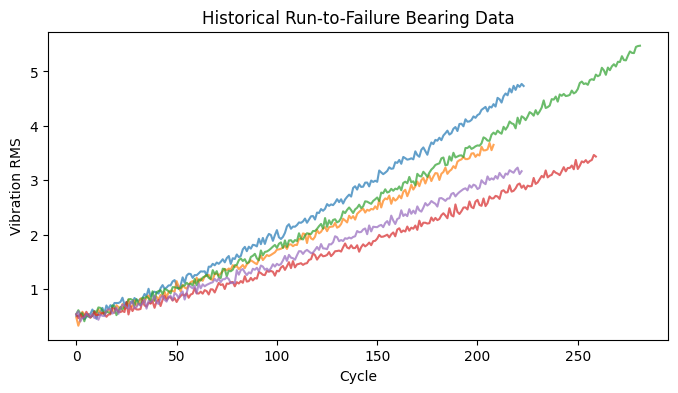

In [3]:
# Visualisasi Run-to-Failure

plt.figure(figsize=(8,4))
for i in range(5):
    plt.plot(all_units[i], alpha=0.7)
plt.xlabel("Cycle")
plt.ylabel("Vibration RMS")
plt.title("Historical Run-to-Failure Bearing Data")
plt.show()

# Setiap kurva: Mulai sehat, Naik, Berakhir saat gagal

In [4]:
# Menentukan Unit Target (Belum Gagal)

target_unit = all_units[-1][:120]  # bearing masih berjalan

# Artinya
# Bearing target baru sampai cycle 120
# Kita tidak tahu kapan dia gagal
# RUL = yang ingin kita estimasi

# Similarity Measurement (DTW)
# Kita pakai Dynamic Time Warping (DTW) karena:
# Kecepatan degradasi beda
# Panjang data beda

from scipy.spatial.distance import euclidean

def dtw_distance(ts1, ts2):
    n, m = len(ts1), len(ts2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0,0] = 0
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(ts1[i-1] - ts2[j-1])
            dtw[i,j] = cost + min(dtw[i-1,j],
                                   dtw[i,j-1],
                                   dtw[i-1,j-1])
    return dtw[n,m]

# Makna DTW
# Cost kecil → pola degradasi mirip
# DTW mengabaikan perbedaan waktu
# Fokus ke bentuk degradasi

In [5]:
# Menghitung Similarity ke Data Historis

distances = []

for i in range(5):
    d = dtw_distance(target_unit, all_units[i])
    distances.append(d)

distances

# Interpretasi:
# Jarak kecil → bearing historis mirip kondisi sekarang
# Kita tidak bandingkan raw cycle, tapi trajectory

[166.50847778477018,
 74.30011697118796,
 276.96843881090723,
 73.82934543386577,
 54.59661450765798]

In [6]:
# Menghitung RUL Historis

rul_historical = []

for i in range(5):
    total_life = len(all_units[i])
    # cari posisi paling mirip (asumsi ujung target sejajar)
    rul_historical.append(total_life - len(target_unit))

# Arti angka
# total_life → umur sampai gagal
# total_life − current_cycle → RUL jika kondisi sama
# Ini asumsi klasik similarity-based:
# > “Kalau sekarang mirip, sisa umurnya mirip”

In [7]:
# Weighted Similarity-Based RUL Estimation

distances = np.array(distances)
weights = 1 / distances
weights = weights / np.sum(weights)

estimated_rul = np.sum(weights * np.array(rul_historical))
estimated_rul

# Penjelasan angka & rumus
# 1 / distance → makin mirip → bobot makin besar
# Normalisasi bobot → total = 1
# RUL = weighted average
# Contoh interpretasi:
# > “Bearing target diperkirakan masih aman sekitar X cycle lagi”

112.67956500756304

In [ ]:
# Treshold-Based RUL Estimation
# estimasi sisa umur berdasarkan jarak kondisi saat ini ke batas kegagalan, menggunakan model dergadasi
# tidak mencari mesin mirip, tapi memodelkan lintasan degradasi
# Threshold = data yang tidak harus sampai gagal, tapi kita tahu batas kegagalannya(threshold)
# contoh threshold: 
# RMS vibrasi > 2.5 mm/s + temperatur > 80 + tool wear > 0.3 mm -> mesin gagal
# threshold berasal dari standar (ISO), experience engineer, desain produk, atau SPC limit

# Degradation Model
# model matematis yang menggambarkan perubahan health indicator terhadap waktu, biasanya monoton meningkat atau menurun
# bentuk umum: linear, exponential, power law, dan stochastic process (wiener, gamma)
# fokusnya bukan sinyal mentah tapi Health Indicator (HI)
# HI bisa berupa: RMS Vibrasi, energy band, PCA score, tool wear length, dan crack length
# syarat HI: monoton, sensitif terhadap degradasi, relatif stabil saat sehat

# Konsep RUL: RUL = waktu saat HI menyentuh treshold - waktu sekarang
# masalahnya: kita belum sampai threshold, maka perlu model degradasi

# Threshold Crossing Time 
# first passage time = waktu pertana kali HI melewati trehsold
# RUl = first passage time - waktu sekarang

# Bagaimana Model dipelajari dari Data:
# kumpulkan data degradasi historis
# estimasi parameter model (MLE/OLS/Regression)
# tentukan threshold
# hitung distribusi waktu ke threshold
# hasilnya bukan satu angka tapi: mean RUL, Variance, dan CI

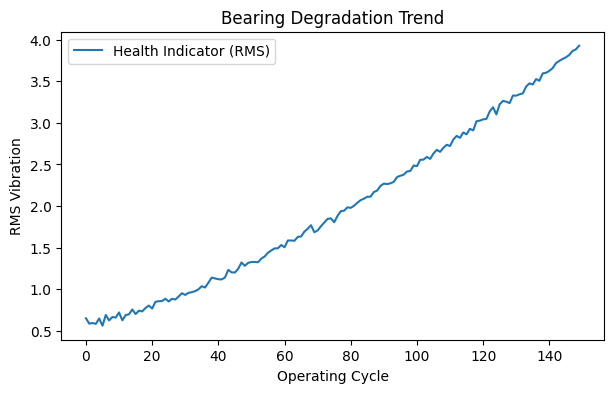

In [8]:
# Studi Kasus
# Estimasi RUL Bearing Mesin Produksi Berbasis Health Indicator & Threshold
# Kondisi nyata yang kita tiru:
# Bearing belum gagal
# Kita tahu batas kegagalan (threshold)
# Kita ingin tahu: berapa lama lagi sampai menyentuh batas itu?


#  Membuat Data Degradasi (Health Indicator)
# Kita pakai RMS vibrasi sebagai health indicator (HI).

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# waktu operasi (cycle)
t = np.arange(0, 150)

# model degradasi sebenarnya (unknown di dunia nyata)
true_degradation_rate = 0.003

HI = 0.6 + true_degradation_rate * t**1.4
HI += 0.03 * np.random.randn(len(t))  # noise sensor

# Makna angka:
# 0.6 → RMS awal bearing sehat
# t^1.4 → degradasi non-linear (realistis)
# 0.003 → severity keausan
# noise 0.03 → fluktuasi operasi & sensor

# Visualisasi Degradasi

plt.figure(figsize=(7,4))
plt.plot(t, HI, label="Health Indicator (RMS)")
plt.xlabel("Operating Cycle")
plt.ylabel("RMS Vibration")
plt.title("Bearing Degradation Trend")
plt.legend()
plt.show()

# Ini ciri khas HI yang baik:
# Rata-rata naik
# Ada noise
# Tidak harus halus

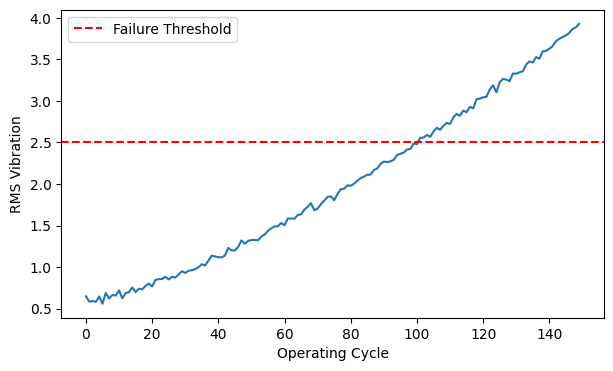

In [10]:
# Menentukan Threshold Kegagalan

failure_threshold = 2.5

# Arti threshold = 2.5
# Bisa berasal dari:
# Standar ISO
# Pengalaman engineer
# Batas aman operasi

# Artinya:
# > Jika RMS ≥ 2.5 → bearing dianggap gagal / tidak aman

# Plot dengan Threshold

plt.figure(figsize=(7,4))
plt.plot(t, HI)
plt.axhline(failure_threshold, color='r', linestyle='--', label="Failure Threshold")
plt.xlabel("Operating Cycle")
plt.ylabel("RMS Vibration")
plt.legend()
plt.show()

In [11]:
# Memilih Model Degradasi (Deterministic)
# Untuk introduction, kita pakai power-law degradation model:
# HI(t) = a \cdot t^b + c
# Kenapa?
# Lebih realistis dari linear
# Banyak dipakai untuk wear & fatigue

# Fit Model ke Data (Regression)

from scipy.optimize import curve_fit

def degradation_model(t, a, b, c):
    return a * t**b + c

params, _ = curve_fit(degradation_model, t, HI)

a_hat, b_hat, c_hat = params
a_hat, b_hat, c_hat

# Interpretasi parameter hasil fitting
# â (scale) → Seberapa cepat degradasi naik
# b̂ (shape) → >1 artinya degradasi makin cepat (accelerating wear)
# ĉ (offset) → Kondisi awal bearing

C:\Users\Robyi\AppData\Local\Temp\ipykernel_2076\2784817298.py:13: RuntimeWarning: divide by zero encountered in power
  return a * t**b + c


(0.0030809854747404753, 1.395073584468364, 0.596492978647481)

In [12]:
# Memprediksi Waktu Menyentuh Threshold
# Kita cari waktu  saat:
# HI(t_f) = \text{threshold}

# Menghitung Time-to-Failure

from scipy.optimize import fsolve

def threshold_equation(t):
    return degradation_model(t, a_hat, b_hat, c_hat) - failure_threshold

t_failure = fsolve(threshold_equation, x0=300)[0]
t_failure

# Arti x0 = 300
# Tebakan awal
# Tidak harus tepat
# Hanya membantu solver konvergen

100.11852134338423

In [13]:
# Menghitung RUL

current_time = t[-1]
RUL = t_failure - current_time
RUL

# Interpretasi:
# t_failure → estimasi waktu gagal
# current_time → kondisi sekarang
# RUL → sisa umur operasi

# Contoh makna:
# > “Bearing diperkirakan masih aman sekitar RUL cycle lagi sebelum menyentuh batas kegagalan.”

-48.88147865661577

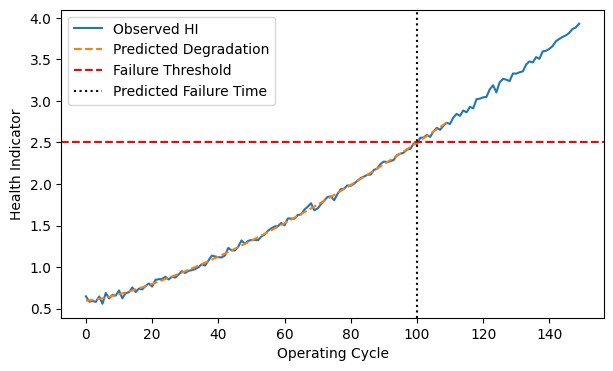

In [14]:
# Visualisasi Prediksi RUL

t_future = np.arange(0, int(t_failure)+10)
HI_pred = degradation_model(t_future, a_hat, b_hat, c_hat)

plt.figure(figsize=(7,4))
plt.plot(t, HI, label="Observed HI")
plt.plot(t_future, HI_pred, '--', label="Predicted Degradation")
plt.axhline(failure_threshold, color='r', linestyle='--', label="Failure Threshold")
plt.axvline(t_failure, color='k', linestyle=':', label="Predicted Failure Time")
plt.xlabel("Operating Cycle")
plt.ylabel("Health Indicator")
plt.legend()
plt.show()

# Interpretasi ala Teknik Industri & Reliability
# Secara engineering decision:
# Maintenance bisa dijadwalkan sebelum threshold
# Tidak perlu tunggu breakdown
# Bisa dihitung:
# Safety margin
# Downtime planning
# Spare part logistics

# Secara SPC & monitoring:
# MSPC → deteksi awal
# Threshold-based RUL → prediksi umur